<center><strong>Deep Learning : Natural Language Processing</strong><br />
<strong><font color="blue">Departemen Informatika - Prodi RKA - Institut Teknologi Sepuluh Nopember</font></strong><br />
</center>

<strong>Outline Hands-On: Sentiment Analysis dengan GRU & BiGRU</strong><br />
<li> Pengenalan Sentiment Analysis & Sequence Model </li>
<li> Arsitektur GRU & BiGRU (Detail) </li>
<li> Anatomi Layer-by-Layer </li>
<li> Dataset IMDB: EDA & Preprocessing </li>
<li> Implementasi Baseline GRU </li>
<li> Bidirectional GRU (BiGRU) </li>
<li> Variasi Arsitektur: Mengganti Layer Output </li>
<li> Variasi Arsitektur: Hybrid Conv1D + BiGRU </li>
<li> Perbandingan Model & Prediksi Review Baru </li>
<li> Tugas Akhir: Sentiment Analysis Dataset Twitter </li>

---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Setup & Persiapan Environment

<p><strong><font color="red">PENTING:</font></strong> Pastikan runtime Google Colab menggunakan <strong>GPU</strong> untuk mempercepat proses training model RNN.</p>

<p>Cara mengaktifkan GPU di Google Colab:</p>
<ol>
    <li>Klik menu <strong>Runtime</strong> → <strong>Change runtime type</strong></li>
    <li>Pada <strong>Hardware accelerator</strong>, pilih <strong>GPU (T4)</strong></li>
    <li>Klik <strong>Save</strong></li>
</ol>

In [ ]:
# Import library yang dibutuhkan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, GRU, Bidirectional, Dense, Dropout,
    SpatialDropout1D, Input, GlobalMaxPooling1D, GlobalAveragePooling1D,
    Conv1D, MaxPooling1D, Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Style plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Cek versi & GPU
print(f"TensorFlow version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU tersedia: {len(gpus)} device")

TensorFlow version: 2.20.0
GPU tersedia: 1 device


---
## 1. Pengenalan Sentiment Analysis & Sequence Model

<p><strong>Sentiment Analysis</strong> adalah task dalam Natural Language Processing (NLP) untuk <em>mengklasifikasikan opini atau emosi</em> dari sebuah teks, biasanya ke dalam kategori <strong>positif</strong>, <strong>negatif</strong>, atau <strong>netral</strong>.</p>

<p>Contoh aplikasi:</p>
<ul>
    <li>Analisis review produk e-commerce (Tokopedia, Shopee)</li>
    <li>Monitoring brand di media sosial (Twitter/X, Instagram)</li>
    <li>Customer feedback analysis</li>
    <li>Analisis sentimen politik/publik terhadap kebijakan</li>
</ul>

<p>Teks adalah data <strong>sequential</strong> — urutan kata sangat penting. Dua kalimat <em>"The food was good, not bad at all"</em> dan <em>"The food was bad, not good at all"</em> memiliki kata yang sama tetapi sentimen berbeda. Karena itu, kita membutuhkan model yang memahami <strong>urutan</strong> kata — yaitu <strong>Recurrent Neural Network (RNN)</strong> dan variannya seperti <strong>GRU</strong> dan <strong>BiGRU</strong>.</p>

---
## 2. Arsitektur GRU & BiGRU (Detail)

<p>Pada bagian ini kita akan melihat <strong>arsitektur internal</strong> dari sel GRU dan BiGRU, bagaimana gate bekerja, bagaimana hidden state di-update, dan bagaimana implementasinya di Keras.</p>

<hr>

### 2.1 Arsitektur GRU (Gated Recurrent Unit)

<p><strong>GRU</strong> diperkenalkan oleh <em>Cho et al. (2014)</em> sebagai penyederhanaan dari LSTM. GRU mengatasi masalah <strong>vanishing gradient</strong> pada vanilla RNN dengan menggunakan <strong>mekanisme gate</strong>, tetapi hanya memiliki <strong>2 gate</strong> (reset & update), lebih sederhana dari LSTM yang punya 3 gate.</p>

<p><strong>Diagram arsitektur sel GRU:</strong></p>

<p align="center">
<img src="https://colah.github.io/posts/2015-08-Understanding-LSTMs/img/LSTM3-var-GRU.png" alt="GRU Cell Architecture" width="600"/>
<br>
<em>Sumber: Christopher Olah, "Understanding LSTM Networks" (colah.github.io, 2015)</em>
</p>

<h4>Penjelasan Detail Komponen GRU:</h4>

<table border="1" cellpadding="8" cellspacing="0">
<tr>
    <th>Simbol</th><th>Nama</th><th>Fungsi</th>
</tr>
<tr>
    <td><strong>x<sub>t</sub></strong></td>
    <td>Input vektor</td>
    <td>Input pada timestep <em>t</em> (misal: word embedding)</td>
</tr>
<tr>
    <td><strong>h<sub>t-1</sub></strong></td>
    <td>Previous hidden state</td>
    <td>Hidden state dari timestep sebelumnya (memori)</td>
</tr>
<tr>
    <td><strong>z<sub>t</sub></strong></td>
    <td>Update gate</td>
    <td>Menentukan seberapa banyak informasi lama yang <strong>dipertahankan</strong></td>
</tr>
<tr>
    <td><strong>r<sub>t</sub></strong></td>
    <td>Reset gate</td>
    <td>Menentukan seberapa banyak informasi lama yang <strong>dilupakan</strong> saat menghitung kandidat</td>
</tr>
<tr>
    <td><strong>h̃<sub>t</sub></strong></td>
    <td>Candidate hidden state</td>
    <td>Kandidat hidden state baru berdasarkan input dan sebagian informasi lama</td>
</tr>
<tr>
    <td><strong>h<sub>t</sub></strong></td>
    <td>Hidden state</td>
    <td>Hidden state final hasil interpolasi antara h<sub>t-1</sub> dan h̃<sub>t</sub></td>
</tr>
</table>

<h4>Formula GRU:</h4>

<p style="font-family: monospace; background-color: #f4f4f4; padding: 10px;">
z<sub>t</sub> = σ(W<sub>z</sub> · x<sub>t</sub> + U<sub>z</sub> · h<sub>t-1</sub> + b<sub>z</sub>)&nbsp;&nbsp;&nbsp;&nbsp;# Update gate<br />
r<sub>t</sub> = σ(W<sub>r</sub> · x<sub>t</sub> + U<sub>r</sub> · h<sub>t-1</sub> + b<sub>r</sub>)&nbsp;&nbsp;&nbsp;&nbsp;# Reset gate<br />
h̃<sub>t</sub> = tanh(W<sub>h</sub> · x<sub>t</sub> + U<sub>h</sub> · (r<sub>t</sub> ⊙ h<sub>t-1</sub>) + b<sub>h</sub>)&nbsp;# Candidate<br />
h<sub>t</sub> = (1 - z<sub>t</sub>) ⊙ h<sub>t-1</sub> + z<sub>t</sub> ⊙ h̃<sub>t</sub>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;# Output
</p>

<p><em>Keterangan: σ adalah sigmoid, ⊙ adalah perkalian elemen-wise (Hadamard product).</em></p>

<h4>Intuisi Gate:</h4>

<ul>
    <li><strong>Update gate (z<sub>t</sub>)</strong> bertindak seperti <em>switch</em>:
        <ul>
            <li>Jika z<sub>t</sub> ≈ 1 → h<sub>t</sub> ≈ h̃<sub>t</sub> (percaya pada informasi baru)</li>
            <li>Jika z<sub>t</sub> ≈ 0 → h<sub>t</sub> ≈ h<sub>t-1</sub> (pertahankan informasi lama)</li>
        </ul>
    </li>
    <li><strong>Reset gate (r<sub>t</sub>)</strong> mengontrol:
        <ul>
            <li>Jika r<sub>t</sub> ≈ 0 → h̃<sub>t</sub> hanya dihitung dari x<sub>t</sub> (mulai "fresh")</li>
            <li>Jika r<sub>t</sub> ≈ 1 → h̃<sub>t</sub> memperhitungkan seluruh h<sub>t-1</sub></li>
        </ul>
    </li>
</ul>

<p><strong>Jumlah parameter GRU:</strong> <code>3 × (units × (input_dim + units) + 2 × units)</code> — faktor <strong>3</strong> karena 3 matriks bobot (update, reset, candidate).</p>

In [ ]:
# Demonstrasi: Membangun 1 layer GRU dan menghitung parameter
test_gru = Sequential([
    Input(shape=(100,)),                     # sequence length 100
    Embedding(input_dim=5000, output_dim=64),# vocab 5000, embed dim 64
    GRU(32)                                   # 32 hidden units
], name='GRU_Demo')

test_gru.summary()

# Verifikasi manual
units, input_dim = 32, 64
manual = 3 * (units * (input_dim + units) + 2 * units)
print(f"\nPerhitungan manual jumlah parameter GRU({units}) dengan input_dim={input_dim}:")
print(f"  3 × ({units} × ({input_dim} + {units}) + 2 × {units}) = {manual}")

Model: "GRU_Demo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         9,408 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329,408 (1.26 MB)

 Trainable params: 329,408 (1.26 MB)

 Non-trainable params: 0 (0.00 B)


Perhitungan manual jumlah parameter GRU(32) dengan input_dim=64:
  3 × (32 × (64 + 32) + 2 × 32) = 9408


<hr>

### 2.2 Arsitektur Bidirectional GRU (BiGRU)

<p><strong>BiGRU</strong> adalah perluasan GRU yang memproses sequence dari <strong>dua arah</strong> sekaligus:</p>

<ul>
    <li><strong>Forward GRU</strong>: membaca dari x<sub>1</sub> → x<sub>2</sub> → ... → x<sub>T</sub> (kiri ke kanan)</li>
    <li><strong>Backward GRU</strong>: membaca dari x<sub>T</sub> → x<sub>T-1</sub> → ... → x<sub>1</sub> (kanan ke kiri)</li>
</ul>

<p>Hidden state dari kedua arah kemudian digabung (biasanya <strong>concatenate</strong>) untuk membentuk representasi akhir.</p>

<p><strong>Diagram arsitektur BiRNN/BiGRU:</strong></p>

<p align="center">
<img src="https://d2l.ai/_images/birnn.svg" alt="Bidirectional RNN Architecture" width="550"/>
<br>
<em>Sumber: Aston Zhang et al., "Dive into Deep Learning" (d2l.ai) — arsitektur BiRNN; BiGRU menggantikan sel RNN dengan sel GRU</em>
</p>

<h4>Penjelasan Detail:</h4>

<table border="1" cellpadding="8" cellspacing="0">
<tr>
    <th>Komponen</th><th>Dimensi</th><th>Keterangan</th>
</tr>
<tr>
    <td>Forward hidden state <strong>→h<sub>t</sub></strong></td>
    <td>h</td>
    <td>Hasil GRU yang memproses dari kiri ke kanan; berisi konteks <em>sebelum</em> timestep t</td>
</tr>
<tr>
    <td>Backward hidden state <strong>←h<sub>t</sub></strong></td>
    <td>h</td>
    <td>Hasil GRU yang memproses dari kanan ke kiri; berisi konteks <em>setelah</em> timestep t</td>
</tr>
<tr>
    <td>Concatenated hidden state <strong>h<sub>t</sub></strong></td>
    <td>2h</td>
    <td>Gabungan konteks dua arah → [→h<sub>t</sub> ; ←h<sub>t</sub>]</td>
</tr>
</table>

<h4>Formula BiGRU:</h4>

<p style="font-family: monospace; background-color: #f4f4f4; padding: 10px;">
→h<sub>t</sub> = GRU<sub>forward</sub>(x<sub>t</sub>, →h<sub>t-1</sub>)<br />
←h<sub>t</sub> = GRU<sub>backward</sub>(x<sub>t</sub>, ←h<sub>t+1</sub>)<br />
h<sub>t</sub> = [→h<sub>t</sub> ; ←h<sub>t</sub>]&nbsp;&nbsp;&nbsp;&nbsp;# concatenate (default)
</p>

<h4>Mengapa BiGRU penting untuk NLP?</h4>

<p>Banyak task bahasa memerlukan <strong>konteks dua arah</strong>. Perhatikan contoh dari slide MIT 6.S191:</p>

<blockquote>
<em>"In France, I had a great time and I learnt some of the <strong>_____</strong> language."</em>
</blockquote>

<p>Untuk memprediksi kata yang hilang (jawaban: <em>French</em>), model perlu:</p>
<ul>
    <li>Konteks kiri: "In France" → petunjuk negara</li>
    <li>Konteks kanan: "language" → petunjuk bahwa kata yang hilang adalah nama bahasa</li>
</ul>

<p>GRU standar (unidirectional) hanya melihat konteks kiri, sehingga sulit memprediksi dengan akurat. BiGRU dapat mempertimbangkan <strong>kedua arah</strong>.</p>

In [ ]:
# Demonstrasi: Membangun 1 layer BiGRU
test_bigru = Sequential([
    Input(shape=(100,)),
    Embedding(input_dim=5000, output_dim=64),
    Bidirectional(GRU(32))                  # Wrapped dengan Bidirectional
], name='BiGRU_Demo')

test_bigru.summary()

print("\nPerhatikan:")
print("  - Output shape Bidirectional(GRU(32)) adalah (None, 64) = 2 × 32")
print("  - Karena forward (32) + backward (32) di-concatenate")
print("  - Jumlah parameter ~2× GRU biasa (ada 2 GRU yang dilatih paralel)")

Model: "BiGRU_Demo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 64)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        18,816 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 338,816 (1.29 MB)

 Trainable params: 338,816 (1.29 MB)

 Non-trainable params: 0 (0.00 B)


Perhatikan:
  - Output shape Bidirectional(GRU(32)) adalah (None, 64) = 2 × 32
  - Karena forward (32) + backward (32) di-concatenate
  - Jumlah parameter ~2× GRU biasa (ada 2 GRU yang dilatih paralel)


<hr>

### 2.3 Perbandingan Visual: GRU vs BiGRU

<p>Mari kita bandingkan flow informasi antara GRU dan BiGRU dengan diagram yang dibuat secara manual:</p>

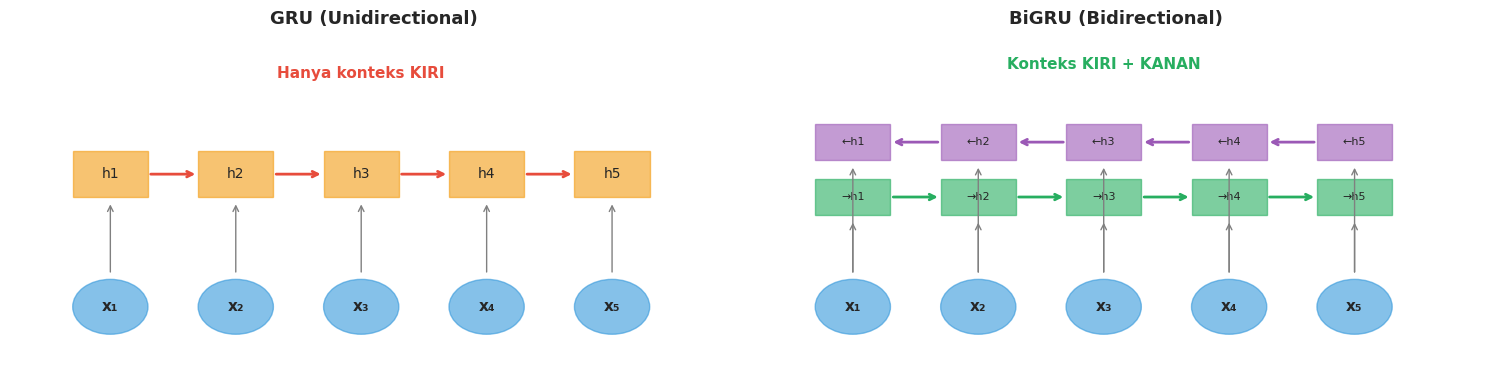

In [ ]:
# Visualisasi schematic GRU vs BiGRU
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

# === GRU (Unidirectional) ===
ax1.set_title('GRU (Unidirectional)', fontsize=13, fontweight='bold')
tokens = ['x₁', 'x₂', 'x₃', 'x₄', 'x₅']
for i, tok in enumerate(tokens):
    ax1.add_patch(plt.Circle((i, 0), 0.3, color='#3498db', alpha=0.6))
    ax1.text(i, 0, tok, ha='center', va='center', fontsize=11, fontweight='bold')
    ax1.add_patch(plt.Rectangle((i-0.3, 1.2), 0.6, 0.5, color='#f39c12', alpha=0.6))
    ax1.text(i, 1.45, f'h{i+1}', ha='center', va='center', fontsize=10)
    ax1.annotate('', xy=(i, 1.15), xytext=(i, 0.35),
                 arrowprops=dict(arrowstyle='->', color='gray'))
    if i < len(tokens) - 1:
        ax1.annotate('', xy=(i+0.7, 1.45), xytext=(i+0.3, 1.45),
                     arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=2))

ax1.text(2, 2.5, 'Hanya konteks KIRI', ha='center', fontsize=11,
         color='#e74c3c', fontweight='bold')
ax1.set_xlim(-0.8, len(tokens)); ax1.set_ylim(-0.8, 3)
ax1.axis('off')

# === BiGRU ===
ax2.set_title('BiGRU (Bidirectional)', fontsize=13, fontweight='bold')
for i, tok in enumerate(tokens):
    ax2.add_patch(plt.Circle((i, 0), 0.3, color='#3498db', alpha=0.6))
    ax2.text(i, 0, tok, ha='center', va='center', fontsize=11, fontweight='bold')
    ax2.add_patch(plt.Rectangle((i-0.3, 1.0), 0.6, 0.4, color='#27ae60', alpha=0.6))
    ax2.text(i, 1.2, f'→h{i+1}', ha='center', va='center', fontsize=8)
    ax2.add_patch(plt.Rectangle((i-0.3, 1.6), 0.6, 0.4, color='#9b59b6', alpha=0.6))
    ax2.text(i, 1.8, f'←h{i+1}', ha='center', va='center', fontsize=8)
    ax2.annotate('', xy=(i, 0.95), xytext=(i, 0.35),
                 arrowprops=dict(arrowstyle='->', color='gray'))
    ax2.annotate('', xy=(i, 1.55), xytext=(i, 0.35),
                 arrowprops=dict(arrowstyle='->', color='gray'))
    if i < len(tokens) - 1:
        ax2.annotate('', xy=(i+0.7, 1.2), xytext=(i+0.3, 1.2),
                     arrowprops=dict(arrowstyle='->', color='#27ae60', lw=2))
    if i > 0:
        ax2.annotate('', xy=(i-0.7, 1.8), xytext=(i-0.3, 1.8),
                     arrowprops=dict(arrowstyle='->', color='#9b59b6', lw=2))

ax2.text(2, 2.6, 'Konteks KIRI + KANAN', ha='center', fontsize=11,
         color='#27ae60', fontweight='bold')
ax2.set_xlim(-0.8, len(tokens)); ax2.set_ylim(-0.8, 3)
ax2.axis('off')

plt.tight_layout()
plt.show()

---
## 3. Anatomi Layer-by-Layer

<p>Sebelum membangun model lengkap, mari kita pahami setiap <strong>layer</strong> yang akan digunakan. Setiap layer di Keras memiliki fungsi spesifik, parameter penting, dan <em>input-output shape</em> yang harus kita pahami.</p>

<p>Kita akan bahas 5 kelompok layer:</p>
<ol>
    <li><strong>Input Layers</strong>: <code>Embedding</code>, <code>SpatialDropout1D</code></li>
    <li><strong>Recurrent Layers</strong>: <code>GRU</code>, <code>Bidirectional</code></li>
    <li><strong>Aggregation Layers</strong>: <code>GlobalMaxPooling1D</code>, <code>GlobalAveragePooling1D</code>, <code>Concatenate</code></li>
    <li><strong>Convolutional Layers</strong>: <code>Conv1D</code>, <code>MaxPooling1D</code></li>
    <li><strong>Output & Regularization</strong>: <code>Dense</code>, <code>Dropout</code></li>
</ol>

### 3.1 Input Layers

#### `Embedding` — Mengubah Token Integer menjadi Vektor

<p><strong>Fungsi:</strong> Mengubah integer token (misal ID kata) menjadi vektor <em>dense</em> bernilai float. Vektor ini yang akan "dipelajari" model — kata-kata dengan makna mirip akan memiliki vektor yang mirip.</p>

<table border="1" cellpadding="6">
<tr><th>Parameter</th><th>Fungsi</th></tr>
<tr><td><code>input_dim</code></td><td>Ukuran vocabulary (jumlah kata unik + token spesial)</td></tr>
<tr><td><code>output_dim</code></td><td>Dimensi vektor embedding (biasanya 50–300)</td></tr>
<tr><td><code>input_length</code></td><td>Panjang sequence input (= MAX_LEN)</td></tr>
</table>

<p><strong>Input shape:</strong> <code>(batch, MAX_LEN)</code> — integer<br>
<strong>Output shape:</strong> <code>(batch, MAX_LEN, output_dim)</code> — float</p>

<p><strong>Contoh:</strong> Token integer <code>[1, 45, 287, 0, 0]</code> (MAX_LEN=5) akan diubah menjadi matriks 5×100 jika <code>output_dim=100</code>. Setiap baris adalah vektor representasi satu kata.</p>

#### `SpatialDropout1D` — Dropout Khusus untuk Embedding

<p><strong>Fungsi:</strong> Dropout yang men-drop <em>seluruh dimensi embedding</em> secara acak (bukan individual elemen). Lebih efektif untuk input embedding karena elemen dalam satu vektor embedding sangat berkorelasi — jika men-drop individual elemen (Dropout biasa), model tetap bisa "mengintip" informasi dari dimensi tetangga.</p>

<table border="1" cellpadding="6">
<tr><th>Parameter</th><th>Fungsi</th></tr>
<tr><td><code>rate</code></td><td>Proporsi dimensi yang di-drop (0.2 = 20%)</td></tr>
</table>

<p><strong>Input/Output shape:</strong> tetap <code>(batch, MAX_LEN, embed_dim)</code></p>

In [ ]:
# Demo: Input Layers
print("=== Demo: Embedding + SpatialDropout1D ===\n")

demo1 = Sequential([
    Input(shape=(10,)),                         # sequence length 10
    Embedding(input_dim=1000, output_dim=16),  # vocab 1000, embed 16
    SpatialDropout1D(0.2)
], name='Demo_Input_Layers')

demo1.summary()

# Coba jalankan dengan input dummy
dummy_input = np.array([[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]])
dummy_output = demo1(dummy_input)
print(f"\nInput shape : {dummy_input.shape}")
print(f"Output shape: {dummy_output.shape}")
print(f"\nContoh output (vektor untuk token pertama, 5 dim pertama):")
print(dummy_output.numpy()[0, 0, :5])

=== Demo: Embedding + SpatialDropout1D ===



Model: "Demo_Input_Layers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 10, 16)         │        16,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 10, 16)         │             0 │
│ (SpatialDropout1D)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,000 (62.50 KB)

 Trainable params: 16,000 (62.50 KB)

 Non-trainable params: 0 (0.00 B)


Input shape : (1, 10)
Output shape: (1, 10, 16)

Contoh output (vektor untuk token pertama, 5 dim pertama):
[-0.01434095  0.01740675 -0.01630293  0.03923155  0.03329803]


### 3.2 Recurrent Layers

#### `GRU` — Gated Recurrent Unit

<p><strong>Fungsi:</strong> Memproses sequence kata-demi-kata, menghasilkan hidden state yang "mengingat" informasi dari timestep sebelumnya. Detail mekanisme gate sudah dibahas di Section 2.1.</p>

<table border="1" cellpadding="6">
<tr><th>Parameter</th><th>Fungsi</th></tr>
<tr><td><code>units</code></td><td>Jumlah hidden units (dimensi hidden state)</td></tr>
<tr><td><code>dropout</code></td><td>Dropout pada koneksi input-to-hidden (0 - 1)</td></tr>
<tr><td><code>recurrent_dropout</code></td><td>Dropout pada koneksi recurrent (hidden-to-hidden); ⚠️ mematikan optimasi cuDNN, training jadi jauh lebih lambat</td></tr>
<tr><td><code>return_sequences</code></td><td><code>False</code> (default): hanya return hidden state timestep terakhir, shape <code>(batch, units)</code>.<br><code>True</code>: return seluruh sequence hidden state, shape <code>(batch, MAX_LEN, units)</code> — wajib untuk stacking atau pooling</td></tr>
</table>

#### `Bidirectional` — Wrapper Dua Arah

<p><strong>Fungsi:</strong> Wrapper yang menduplikasi layer recurrent menjadi 2 instance — satu forward, satu backward — lalu menggabungkan outputnya.</p>

<table border="1" cellpadding="6">
<tr><th>Parameter</th><th>Fungsi</th></tr>
<tr><td><code>layer</code></td><td>Layer recurrent yang akan dibungkus, misal <code>GRU(64)</code></td></tr>
<tr><td><code>merge_mode</code></td><td>Cara menggabungkan: <code>'concat'</code> (default, gabung → 2×units), <code>'sum'</code>, <code>'mul'</code>, <code>'ave'</code>, atau <code>None</code> (list 2 tensor terpisah)</td></tr>
</table>

<p><strong>Output shape</strong> (dengan <code>merge_mode='concat'</code>, default):</p>
<ul>
    <li>Jika <code>return_sequences=False</code>: <code>(batch, 2×units)</code></li>
    <li>Jika <code>return_sequences=True</code>: <code>(batch, MAX_LEN, 2×units)</code></li>
</ul>

In [ ]:
# Demo: Recurrent Layers
print("=== Demo 1: GRU return_sequences=False (default) ===\n")
demo2a = Sequential([
    Input(shape=(10,)),
    Embedding(1000, 16),
    GRU(32)  # default: return_sequences=False
], name='Demo_GRU_Last')
demo2a.summary()
out = demo2a(np.array([[1,2,3,4,5,6,7,8,9,10]]))
print(f"Output shape: {out.shape}  ← hanya timestep terakhir\n")

print("=== Demo 2: GRU return_sequences=True ===\n")
demo2b = Sequential([
    Input(shape=(10,)),
    Embedding(1000, 16),
    GRU(32, return_sequences=True)  # <-- return semua timestep
], name='Demo_GRU_All')
demo2b.summary()
out = demo2b(np.array([[1,2,3,4,5,6,7,8,9,10]]))
print(f"Output shape: {out.shape}  ← semua timestep\n")

print("=== Demo 3: Bidirectional(GRU) ===\n")
demo2c = Sequential([
    Input(shape=(10,)),
    Embedding(1000, 16),
    Bidirectional(GRU(32))
], name='Demo_BiGRU')
demo2c.summary()
out = demo2c(np.array([[1,2,3,4,5,6,7,8,9,10]]))
print(f"Output shape: {out.shape}  ← 2 × 32 = 64 (concat forward + backward)")

=== Demo 1: GRU return_sequences=False (default) ===



Model: "Demo_GRU_Last"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 10, 16)         │        16,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 32)             │         4,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,800 (81.25 KB)

 Trainable params: 20,800 (81.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 10, 16)         │        16,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │         9,600 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,600 (100.00 KB)

 Trainable params: 25,600 (100.00 KB)

 Non-trainable params: 0 (0.00 B)

Output shape: (1, 64)  ← 2 × 32 = 64 (concat forward + backward)


### 3.3 Aggregation Layers (Pooling & Concat)

<p>Setelah <code>return_sequences=True</code>, kita memiliki output shape <code>(batch, MAX_LEN, units)</code>. Kita perlu "mereduksi" dimensi MAX_LEN menjadi satu vektor sebelum masuk ke Dense.</p>

#### `GlobalMaxPooling1D`

<p><strong>Fungsi:</strong> Untuk setiap dimensi, ambil <strong>nilai maksimum</strong> dari seluruh timestep. Intuisinya: menangkap fitur paling "mencolok" dari sequence.</p>

<p><strong>Input:</strong> <code>(batch, T, D)</code> → <strong>Output:</strong> <code>(batch, D)</code></p>

#### `GlobalAveragePooling1D`

<p><strong>Fungsi:</strong> Untuk setiap dimensi, ambil <strong>rata-rata</strong> dari seluruh timestep. Intuisinya: menangkap fitur "rata-rata" atau keseluruhan tone.</p>

#### `Concatenate`

<p><strong>Fungsi:</strong> Menggabungkan beberapa tensor di sepanjang axis tertentu (default axis=-1). Dipakai misalnya untuk gabungkan MaxPool dan AvgPool agar model dapat kedua informasi.</p>

<p><strong>Input:</strong> list tensor dengan dimensi yang sama kecuali axis concat → <strong>Output:</strong> tensor dengan axis concat dijumlah</p>

In [ ]:
# Demo: Aggregation Layers
print("=== Demo: GlobalMaxPool, GlobalAvgPool, Concatenate ===\n")

# Input: (batch=1, timesteps=10, features=32)
dummy = np.random.randn(1, 10, 32).astype(np.float32)

# GlobalMaxPooling1D
max_layer = GlobalMaxPooling1D()
max_out = max_layer(dummy)
print(f"GlobalMaxPooling1D:    input {dummy.shape}  →  output {max_out.shape}")

# GlobalAveragePooling1D
avg_layer = GlobalAveragePooling1D()
avg_out = avg_layer(dummy)
print(f"GlobalAveragePooling1D: input {dummy.shape}  →  output {avg_out.shape}")

# Concatenate (gabung 2 tensor di axis terakhir)
concat_layer = Concatenate()
cat_out = concat_layer([max_out, avg_out])
print(f"Concatenate([max, avg]): input 2×{max_out.shape}  →  output {cat_out.shape}")

print("\nContoh arsitektur BiGRU → GlobalMaxPool:")
demo3 = Sequential([
    Input(shape=(10,)),
    Embedding(1000, 16),
    Bidirectional(GRU(32, return_sequences=True)),  # (None, 10, 64)
    GlobalMaxPooling1D()                             # (None, 64)
], name='Demo_Aggregation')
demo3.summary()

=== Demo: GlobalMaxPool, GlobalAvgPool, Concatenate ===

GlobalMaxPooling1D:    input (1, 10, 32)  →  output (1, 32)
GlobalAveragePooling1D: input (1, 10, 32)  →  output (1, 32)
Concatenate([max, avg]): input 2×(1, 32)  →  output (1, 64)

Contoh arsitektur BiGRU → GlobalMaxPool:


Model: "Demo_Aggregation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 10, 16)         │        16,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 10, 64)         │         9,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,600 (100.00 KB)

 Trainable params: 25,600 (100.00 KB)

 Non-trainable params: 0 (0.00 B)

### 3.4 Convolutional Layers (untuk Hybrid Model)

#### `Conv1D` — Konvolusi 1 Dimensi

<p><strong>Fungsi:</strong> Men-scan sequence dengan "window" sepanjang <code>kernel_size</code> dan menghasilkan <em>feature map</em>. Dalam NLP, Conv1D menangkap pola <strong>n-gram</strong> — misal bigram "not good", trigram "very very good".</p>

<table border="1" cellpadding="6">
<tr><th>Parameter</th><th>Fungsi</th></tr>
<tr><td><code>filters</code></td><td>Jumlah filter (= jumlah feature map output)</td></tr>
<tr><td><code>kernel_size</code></td><td>Panjang window konvolusi (biasanya 3, 5, 7)</td></tr>
<tr><td><code>padding</code></td><td><code>'same'</code>: output panjang sama dengan input; <code>'valid'</code>: output lebih pendek</td></tr>
<tr><td><code>activation</code></td><td>Biasanya <code>'relu'</code></td></tr>
</table>

<p><strong>Input:</strong> <code>(batch, T, D)</code> → <strong>Output:</strong> <code>(batch, T', filters)</code></p>

#### `MaxPooling1D` — Reduksi Timestep

<p><strong>Fungsi:</strong> Mengecilkan dimensi timestep dengan mengambil max dari window berukuran <code>pool_size</code>. Misal <code>pool_size=2</code> akan memperpendek sequence menjadi setengah.</p>

<p><strong>Perbedaan dengan <code>GlobalMaxPooling1D</code>:</strong></p>
<ul>
    <li><code>MaxPooling1D(2)</code>: local window, memperpendek tapi masih ada dimensi timestep</li>
    <li><code>GlobalMaxPooling1D()</code>: seluruh sequence, menghilangkan dimensi timestep</li>
</ul>

In [ ]:
# Demo: Convolutional Layers
print("=== Demo: Conv1D + MaxPooling1D ===\n")

demo4 = Sequential([
    Input(shape=(200,)),
    Embedding(1000, 64),                                    # (None, 200, 64)
    Conv1D(filters=32, kernel_size=5, padding='same',
           activation='relu'),                               # (None, 200, 32)
    MaxPooling1D(pool_size=2),                               # (None, 100, 32)
    Bidirectional(GRU(16))                                   # (None, 32)
], name='Demo_Conv_BiGRU')

demo4.summary()

print("\nPerhatikan perubahan shape:")
print("  - Embedding                 → (None, 200, 64)")
print("  - Conv1D(32, kernel=5)      → (None, 200, 32)  [feature map 32 channel]")
print("  - MaxPooling1D(2)           → (None, 100, 32)  [sequence dipendek 1/2]")
print("  - Bidirectional(GRU(16))    → (None, 32)       [16 forward + 16 backward]")

=== Demo: Conv1D + MaxPooling1D ===



Model: "Demo_Conv_BiGRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 200, 64)        │        64,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 200, 32)        │        10,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 32)             │         4,800 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,072 (308.88 KB)

 Trainable params: 79,072 (308.88 KB)

 Non-trainable params: 0 (0.00 B)


Perhatikan perubahan shape:
  - Embedding                 → (None, 200, 64)
  - Conv1D(32, kernel=5)      → (None, 200, 32)  [feature map 32 channel]
  - MaxPooling1D(2)           → (None, 100, 32)  [sequence dipendek 1/2]
  - Bidirectional(GRU(16))    → (None, 32)       [16 forward + 16 backward]


### 3.5 Output & Regularization

#### `Dense` — Fully Connected Layer

<p><strong>Fungsi:</strong> Layer linear standar <code>y = Wx + b</code>, diikuti activation function. Dipakai sebagai:</p>
<ul>
    <li><strong>Hidden layer</strong> (menambah kapasitas model) — gunakan <code>activation='relu'</code></li>
    <li><strong>Output layer</strong> — untuk klasifikasi biner gunakan <code>Dense(1, 'sigmoid')</code>; multi-kelas gunakan <code>Dense(n_classes, 'softmax')</code></li>
</ul>

#### `Dropout` — Regularisasi Standar

<p><strong>Fungsi:</strong> Secara acak men-drop <code>rate</code> persen unit saat training. Mencegah overfitting. Biasanya ditaruh setelah Dense hidden layer.</p>

<table border="1" cellpadding="6">
<tr><th>Parameter</th><th>Fungsi</th></tr>
<tr><td><code>rate</code></td><td>Proporsi unit yang di-drop (biasanya 0.2–0.5)</td></tr>
</table>

In [ ]:
# Demo: Output Layers (binary vs multi-class)
print("=== Demo 1: Output binary classification ===\n")
demo5a = Sequential([
    Input(shape=(64,)),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')    # <-- 1 unit, sigmoid, untuk biner
], name='Demo_Binary_Output')
demo5a.summary()

print("\n=== Demo 2: Output multi-class (3 kelas) ===\n")
demo5b = Sequential([
    Input(shape=(64,)),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')    # <-- 3 unit, softmax, untuk multi-kelas
], name='Demo_Multiclass_Output')
demo5b.summary()

print("\nPerbedaan kunci:")
print("  - Binary    : Dense(1, 'sigmoid')  + loss='binary_crossentropy'")
print("  - Multiclass: Dense(n, 'softmax')  + loss='categorical_crossentropy'")

=== Demo 1: Output binary classification ===



Model: "Demo_Binary_Output"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,113 (8.25 KB)

 Trainable params: 2,113 (8.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,179 (8.51 KB)

 Trainable params: 2,179 (8.51 KB)

 Non-trainable params: 0 (0.00 B)


Perbedaan kunci:
  - Binary    : Dense(1, 'sigmoid')  + loss='binary_crossentropy'
  - Multiclass: Dense(n, 'softmax')  + loss='categorical_crossentropy'


### 3.6 Ringkasan Layer

<table border="1" cellpadding="8" cellspacing="0">
<tr><th>Layer</th><th>Kapan Dipakai</th><th>Input Shape</th><th>Output Shape</th></tr>
<tr><td><code>Embedding</code></td><td>Layer pertama untuk input teks</td><td>(B, T)</td><td>(B, T, D)</td></tr>
<tr><td><code>SpatialDropout1D</code></td><td>Setelah Embedding, untuk regularisasi</td><td>(B, T, D)</td><td>(B, T, D)</td></tr>
<tr><td><code>Conv1D</code></td><td>Menangkap pola n-gram lokal</td><td>(B, T, D)</td><td>(B, T', F)</td></tr>
<tr><td><code>MaxPooling1D(k)</code></td><td>Memperpendek sequence</td><td>(B, T, F)</td><td>(B, T/k, F)</td></tr>
<tr><td><code>GRU(U)</code></td><td>Modeling sequence 1-arah</td><td>(B, T, D)</td><td>(B, U) atau (B, T, U)</td></tr>
<tr><td><code>Bidirectional(GRU(U))</code></td><td>Modeling sequence 2-arah</td><td>(B, T, D)</td><td>(B, 2U) atau (B, T, 2U)</td></tr>
<tr><td><code>GlobalMaxPooling1D</code></td><td>Ambil fitur mencolok dari sequence</td><td>(B, T, D)</td><td>(B, D)</td></tr>
<tr><td><code>GlobalAveragePooling1D</code></td><td>Ambil fitur rata-rata dari sequence</td><td>(B, T, D)</td><td>(B, D)</td></tr>
<tr><td><code>Concatenate</code></td><td>Menggabung beberapa tensor</td><td>list [(B, D1), (B, D2)]</td><td>(B, D1+D2)</td></tr>
<tr><td><code>Dense(U, act)</code></td><td>Hidden/output layer</td><td>(B, D)</td><td>(B, U)</td></tr>
<tr><td><code>Dropout(r)</code></td><td>Regularisasi di antara Dense</td><td>(B, D)</td><td>(B, D)</td></tr>
</table>
<p><em>Keterangan: B=batch, T=timesteps, D=features, U=units, F=filters.</em></p>

<h3><font color="blue">Latihan 1:</font></h3>

<ul>
    <li>Gunakan table di atas untuk <strong>menggambar di kertas</strong> transformasi shape untuk arsitektur berikut:
        <code>Input(200) → Embedding(10000, 100) → Bidirectional(GRU(64, return_sequences=True)) → GlobalMaxPooling1D() → Dense(1, sigmoid)</code>
    </li>
    <li>Bangun model di atas di Keras dan verifikasi shape-nya dengan <code>model.summary()</code>.</li>
    <li>Hitung manual jumlah parameter <strong>Bidirectional(GRU(64))</strong> dengan input_dim=100. Bandingkan dengan output <code>model.summary()</code>.</li>
</ul>

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Bidirectional, GRU, GlobalMaxPooling1D, Dense

model = Sequential([
    Input(shape=(200,)),
    Embedding(input_dim=10000, output_dim=100),
    Bidirectional(GRU(units=64, return_sequences=True)),
    GlobalMaxPooling1D(),
    Dense(units=1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 200, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 200, 128)       │        63,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,063,873 (4.06 MB)

 Trainable params: 1,063,873 (4.06 MB)

 Non-trainable params: 0 (0.00 B)

### Latihan 1 (Bagian 3.6 Ringkasan Layer)

#### 1. Transformasi Shape Arsitektur (Manual)
Berdasarkan tabel ringkasan *layer*, berikut adalah transformasi *shape* dari awal hingga akhir. Kita menggunakan `None` (atau $B$) untuk merepresentasikan dimensi *batch size* yang fleksibel.

* **`Input(200)`** $\rightarrow$ Output Shape: `(None, 200)`
    *(Input teks dengan panjang sequence $T=200$)*
* **`Embedding(10000, 100)`** $\rightarrow$ Output Shape: `(None, 200, 100)`
    *(Mengubah setiap 200 token menjadi vektor berdimensi $D=100$)*
* **`Bidirectional(GRU(64, return_sequences=True))`** $\rightarrow$ Output Shape: `(None, 200, 128)`
    *(Pemrosesan 2 arah: $U=64$, sehingga total fitur menjadi $2U = 128$. `return_sequences=True` mempertahankan dimensi waktu $T=200$)*
* **`GlobalMaxPooling1D()`** $\rightarrow$ Output Shape: `(None, 128)`
    *(Mengambil nilai maksimum di sepanjang dimensi waktu, menghilangkan dimensi $T$)*
* **`Dense(1, sigmoid)`** $\rightarrow$ Output Shape: `(None, 1)`
    *(Layer output untuk klasifikasi biner)*

#### 3. Hitung Manual Parameter `Bidirectional(GRU(64))` dengan `input_dim=100` (Versi Detail)

Untuk menghitung parameter pada GRU secara presisi, kita perlu membedah komponen di dalamnya. GRU memiliki 3 *gate* utama untuk mengontrol informasi: *Update gate*, *Reset gate*, dan *New State/Candidate*.

Pada TensorFlow/Keras modern, *layer* GRU secara *default* menggunakan arsitektur `reset_after=True` (agar kompatibel dengan optimasi cuDNN). Artinya, sistem memisahkan *bias* untuk *input* dan *bias* untuk *hidden state*.

**Langkah 1: Menghitung Parameter untuk 1 Arah (Single GRU)**
Diketahui:
* Dimensi input ($D$) = 100
* Jumlah unit ($U$) = 64
* Jumlah *gate* ($G$) = 3

Mari kita hitung masing-masing matriks bobot (*weights*) dan *bias*-nya:
1. **Bobot Input ($W_{input}$):** Menghubungkan fitur input ke ketiga *gate*.
   $$\text{Parameter} = D \times U \times G = 100 \times 64 \times 3 = 19.200$$

2. **Bobot Recurrent/Hidden ($W_{hidden}$):** Menghubungkan *hidden state* dari *timestep* sebelumnya ke ketiga *gate*.
   $$\text{Parameter} = U \times U \times G = 64 \times 64 \times 3 = 12.288$$

3. **Bias ($B$):** Memiliki 2 set *bias* independen (untuk bagian input dan bagian *hidden*) yang masing-masing dialokasikan untuk 3 *gate*.
   $$\text{Parameter} = 2 \times U \times G = 2 \times 64 \times 3 = 384$$

**Total Parameter 1 Arah (Forward):**
$$\text{Total}_{single} = W_{input} + W_{hidden} + B$$
$$\text{Total}_{single} = 19.200 + 12.288 + 384 = 31.872$$

**Langkah 2: Menghitung Parameter Bidirectional**
Fungsi `Bidirectional` secara harfiah membangun dan menjalankan dua buah layer GRU yang terpisah: satu untuk membaca urutan secara maju (*forward*), dan satu lagi membaca mundur (*backward*).

$$\text{Total}_{bidirectional} = \text{Total}_{single} \times 2$$
$$\text{Total}_{bidirectional} = 31.872 \times 2 = 63.744$$

**Kesimpulan:**
Jumlah parameter yang dihitung secara manual adalah **63.744**. Angka ini akan sama persis dengan yang ditampilkan pada kolom `Param #` di output `model.summary()`.

---
## 4. Dataset IMDB: EDA & Preprocessing

<p><strong>IMDB</strong> adalah dataset klasik untuk sentiment analysis:</p>
<ul>
    <li><strong>50.000 ulasan film</strong> (25.000 train + 25.000 test)</li>
    <li>Label biner: <strong>1 = positif</strong>, <strong>0 = negatif</strong></li>
    <li>Dataset seimbang (50/50 antar kelas)</li>
    <li>Sudah ter-<em>tokenize</em> menjadi integer (setiap integer mewakili satu kata)</li>
</ul>

### 4.1 Load Dataset

In [ ]:
# Konfigurasi global
VOCAB_SIZE = 20000    # Hanya ambil 10.000 kata yang paling sering muncul
MAX_LEN = 200         # Setiap review dipotong/di-padding ke 200 token
EMBEDDING_DIM = 100   # Dimensi vektor embedding

# Load dataset
print("Loading IMDB dataset...")
(x_train_raw, y_train), (x_test_raw, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print(f"Training samples: {len(x_train_raw)}")
print(f"Test samples    : {len(x_test_raw)}")
print(f"\nContoh review (integer ids): {x_train_raw[0][:20]}...")
print(f"Label                       : {y_train[0]}  ({'positive' if y_train[0]==1 else 'negative'})")

Loading IMDB dataset...
Training samples: 25000
Test samples    : 25000

Contoh review (integer ids): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]...
Label                       : 1  (positive)


### 4.2 Exploratory Data Analysis (EDA)

<p>Sebelum training, kita pahami dulu karakteristik data dengan beberapa analisis:</p>
<ol>
    <li>Distribusi label (apakah seimbang?)</li>
    <li>Distribusi panjang review</li>
    <li>Perbandingan panjang review per kelas</li>
    <li>Kata-kata paling sering muncul per kelas</li>
</ol>

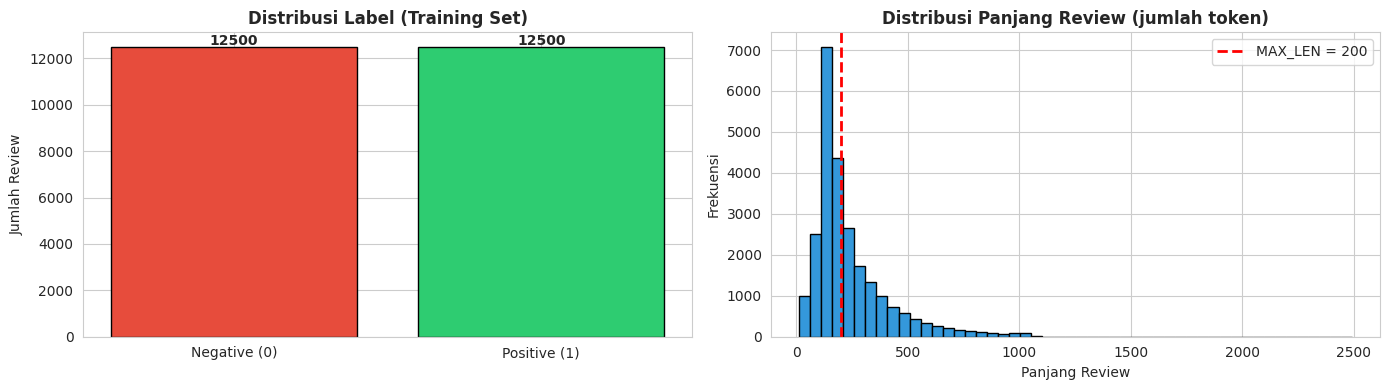


Statistik panjang review:
  Mean  : 238.7
  Median: 178.0
  Max   : 2494
  Min   : 11

Review > MAX_LEN (200): 42.71%


In [ ]:
# EDA 1: Distribusi label & panjang review
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot 1: Distribusi label
train_labels = pd.Series(y_train).value_counts().sort_index()
axes[0].bar(['Negative (0)', 'Positive (1)'], train_labels.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Distribusi Label (Training Set)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Review')
for i, v in enumerate(train_labels.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Plot 2: Distribusi panjang review
review_lengths = [len(r) for r in x_train_raw]
axes[1].hist(review_lengths, bins=50, color='#3498db', edgecolor='black')
axes[1].axvline(MAX_LEN, color='red', linestyle='--', linewidth=2,
                label=f'MAX_LEN = {MAX_LEN}')
axes[1].set_title('Distribusi Panjang Review (jumlah token)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Panjang Review'); axes[1].set_ylabel('Frekuensi')
axes[1].legend()

plt.tight_layout(); plt.show()

print(f"\nStatistik panjang review:")
print(f"  Mean  : {np.mean(review_lengths):.1f}")
print(f"  Median: {np.median(review_lengths):.1f}")
print(f"  Max   : {np.max(review_lengths)}")
print(f"  Min   : {np.min(review_lengths)}")
print(f"\nReview > MAX_LEN ({MAX_LEN}): "
      f"{sum(1 for l in review_lengths if l > MAX_LEN)/len(review_lengths)*100:.2f}%")

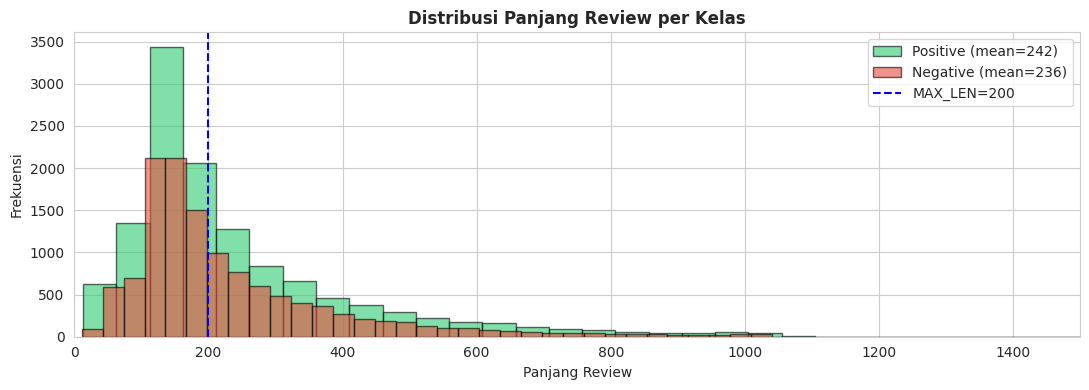

Mean panjang review — Positive: 241.6, Negative: 235.9


In [ ]:
# EDA 2: Perbandingan panjang review per kelas
pos_lengths = [len(r) for r, y in zip(x_train_raw, y_train) if y == 1]
neg_lengths = [len(r) for r, y in zip(x_train_raw, y_train) if y == 0]

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(pos_lengths, bins=50, alpha=0.6, color='#2ecc71',
        label=f'Positive (mean={np.mean(pos_lengths):.0f})', edgecolor='black')
ax.hist(neg_lengths, bins=50, alpha=0.6, color='#e74c3c',
        label=f'Negative (mean={np.mean(neg_lengths):.0f})', edgecolor='black')
ax.axvline(MAX_LEN, color='blue', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
ax.set_title('Distribusi Panjang Review per Kelas', fontweight='bold')
ax.set_xlabel('Panjang Review'); ax.set_ylabel('Frekuensi')
ax.set_xlim(0, 1500)
ax.legend()
plt.tight_layout(); plt.show()

print(f"Mean panjang review — Positive: {np.mean(pos_lengths):.1f}, Negative: {np.mean(neg_lengths):.1f}")

In [ ]:
# EDA 3: Mempersiapkan decoder untuk konversi integer -> kata
word_index = imdb.get_word_index()
# Keras menggunakan offset: 0=pad, 1=start, 2=unknown, 3=unused
index_word = {v + 3: k for k, v in word_index.items()}
index_word[0] = '<PAD>'
index_word[1] = '<START>'
index_word[2] = '<UNK>'
index_word[3] = '<UNUSED>'

def decode_review(encoded_review):
    return ' '.join([index_word.get(i, '?') for i in encoded_review])

# Contoh 2 review
for i in [0, 1]:
    label = 'POSITIVE' if y_train[i] == 1 else 'NEGATIVE'
    print(f"--- Review #{i} [{label}] ---")
    print(decode_review(x_train_raw[i])[:350] + "...\n")

--- Review #0 [POSITIVE] ---
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film t...

--- Review #1 [NEGATIVE] ---
<START> big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horror movies and i've seen hundreds but this had got to be on of the worst ever made the plot is paper thin and ridiculous the acting is an abomination the script is completely laughable the best is the end showdown wi...



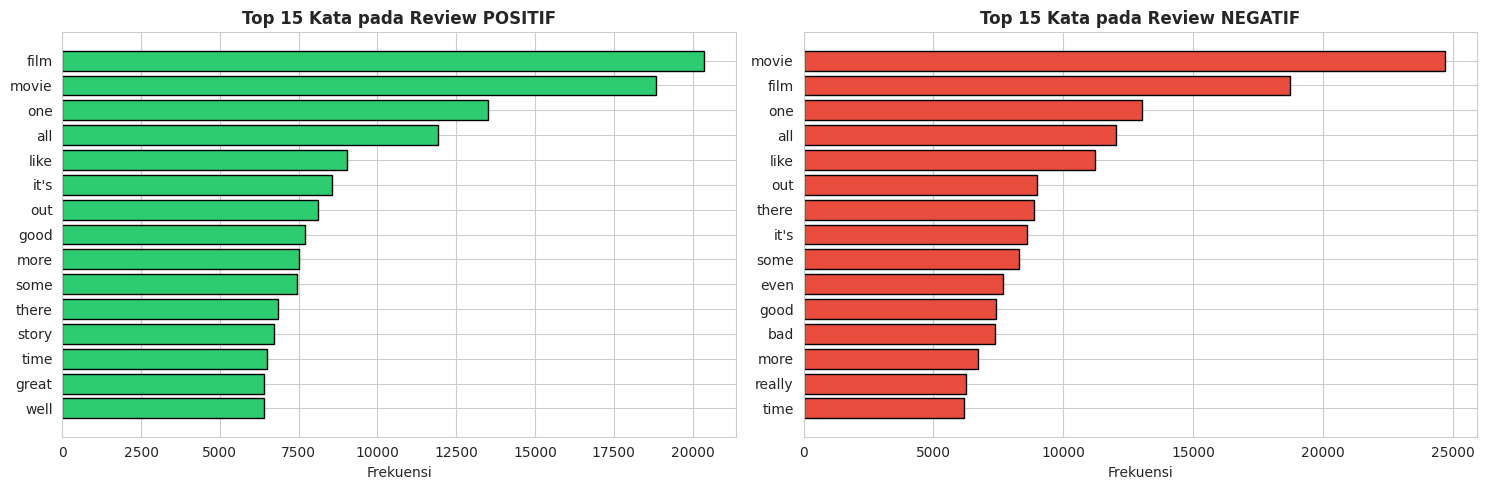

In [ ]:
# EDA 4: Kata-kata paling sering muncul per kelas
stopwords = {'the','a','an','and','or','but','is','are','was','were','be','been',
             'being','have','has','had','do','does','did','will','would','can',
             'could','should','may','might','must','shall','of','in','on','at',
             'to','for','with','from','by','about','as','it','this','that','these',
             'those','i','you','he','she','we','they','his','her','my','your','our',
             'their','him','me','us','them','what','which','who','when','where','why',
             'how','so','if','then','than','too','very','just','also','only','not',
             '<PAD>','<START>','<UNK>','<UNUSED>','s','t','br'}

def top_words(reviews, labels, target_label, topk=15):
    counter = Counter()
    for review, y in zip(reviews, labels):
        if y == target_label:
            for tok in review:
                word = index_word.get(tok, '?')
                if word not in stopwords and len(word) > 2:
                    counter[word] += 1
    return counter.most_common(topk)

top_pos = top_words(x_train_raw, y_train, target_label=1, topk=15)
top_neg = top_words(x_train_raw, y_train, target_label=0, topk=15)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

words_p = [w for w, _ in top_pos][::-1]
counts_p = [c for _, c in top_pos][::-1]
axes[0].barh(words_p, counts_p, color='#2ecc71', edgecolor='black')
axes[0].set_title('Top 15 Kata pada Review POSITIF', fontweight='bold')
axes[0].set_xlabel('Frekuensi')

words_n = [w for w, _ in top_neg][::-1]
counts_n = [c for _, c in top_neg][::-1]
axes[1].barh(words_n, counts_n, color='#e74c3c', edgecolor='black')
axes[1].set_title('Top 15 Kata pada Review NEGATIF', fontweight='bold')
axes[1].set_xlabel('Frekuensi')

plt.tight_layout(); plt.show()

<p><strong>Observasi dari EDA:</strong></p>
<ul>
    <li>Dataset <strong>seimbang</strong> (50/50) → tidak perlu handling class imbalance</li>
    <li>Median panjang review ~178 token → <code>MAX_LEN=200</code> mencakup sebagian besar review</li>
    <li>Panjang review positif dan negatif cukup <strong>mirip</strong> → panjang bukan feature pembeda</li>
</ul>

### 4.3 Preprocessing: Padding & Splitting

<p>Setelah EDA, kita lakukan preprocessing untuk menyiapkan data ke format yang bisa diproses model:</p>

<ol>
    <li><strong>Padding & Truncating</strong> — menyamakan panjang semua review ke <code>MAX_LEN</code>:
        <ul>
            <li>Review lebih pendek → di-<em>pad</em> dengan 0 di depan (<code>padding='pre'</code>)</li>
            <li>Review lebih panjang → di-<em>truncate</em> (<code>truncating='pre'</code>, memotong awal)</li>
        </ul>
    </li>
    <li><strong>Train/Validation Split</strong> — pisahkan 20% data training untuk validasi, dengan <code>stratify</code> agar proporsi kelas tetap seimbang</li>
</ol>

<p><strong>Catatan tentang <code>pre</code> vs <code>post</code>:</strong></p>
<ul>
    <li><code>padding='pre'</code> (default): 0 di <strong>depan</strong> — sering lebih baik untuk RNN</li>
    <li><code>truncating='pre'</code>: memotong di <strong>awal</strong> — menjaga bagian akhir review (biasanya lebih informatif)</li>
</ul>

In [ ]:
# Padding sequence ke panjang tetap
x_train_padded = pad_sequences(x_train_raw, maxlen=MAX_LEN, padding='post', truncating='post')
x_test         = pad_sequences(x_test_raw,  maxlen=MAX_LEN, padding='post', truncating='post')

# Split training → train + validation (80/20, stratified)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_padded, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)

print(f"Training  : {x_train.shape}")
print(f"Validation: {x_val.shape}")
print(f"Test      : {x_test.shape}")
print(f"\nContoh setelah padding (20 token pertama):")
print(x_train[0][:20])
print(f"\nCek balance setelah split:")
print(f"  Train: pos={np.sum(y_train==1)}, neg={np.sum(y_train==0)}")
print(f"  Val  : pos={np.sum(y_val==1)}, neg={np.sum(y_val==0)}")

Training  : (20000, 200)
Validation: (5000, 200)
Test      : (25000, 200)

Contoh setelah padding (20 token pertama):
[   1  806    8  135   13   28   57  326   51  363    9  399  252  202
  178  102   40 1354  778  449]

Cek balance setelah split:
  Train: pos=10000, neg=10000
  Val  : pos=2500, neg=2500


<h3><font color="blue">Latihan 2:</font></h3>

<ul>
    <li>Hitung berapa persen <strong>token <code>&lt;UNK&gt;</code></strong> (integer 2) dalam data training. Apakah proporsinya signifikan?</li>
    <li>Coba ganti <code>VOCAB_SIZE</code> menjadi <strong>5000</strong> dan <strong>20000</strong>. Bagaimana pengaruhnya ke proporsi <code>&lt;UNK&gt;</code>?</li>
    <li>Coba ganti <code>truncating='pre'</code> menjadi <code>truncating='post'</code>. Menurut Anda mana yang lebih baik untuk sentiment analysis dan mengapa?</li>
</ul>

<p><strong>Hint UNK proportion:</strong></p>

```python
unk_count = sum(1 for r in x_train_raw for t in r if t == 2)
total = sum(len(r) for r in x_train_raw)
print(f"UNK ratio: {unk_count/total*100:.2f}%")
```

In [ ]:
unk_count = sum(1 for r in x_train_raw for t in r if t == 2)
total = sum(len(r) for r in x_train_raw)
print(f"UNK ratio: {unk_count/total*100:.2f}%")

UNK ratio: 2.77%


### Latihan 3

#### 1. Berapa persen token <UNK>?

Ada sekitar 5.72% UNK ratio di data training

#### 2. Bagaimana pengaruh proporsi <UNK> terhadap vocab size?

5000 -> 9.93%

20000 -> 2.77%

Kesimpulan: Semakin sedikit vocab size, semakin banyak token <UNK> nya dan begitupun sebaliknya.

#### 3. Perbandingan `truncating='pre'` vs `truncating='post'`
* **`truncating='pre'`**: Jika panjang teks melebihi `MAX_LEN`, sistem akan membuang kata-kata yang ada di **awal** teks, sehingga bagian akhir teks tetap dipertahankan.
* **`truncating='post'`**: Jika panjang teks melebihi `MAX_LEN`, sistem akan membuang kata-kata yang ada di **akhir** teks, sehingga bagian awal teks yang dipertahankan.

#### Mana yang Lebih Baik untuk Sentiment Analysis?
Secara umum, **`truncating='pre'` jauh lebih disarankan** dan sering menjadi standar (*best practice*) untuk *sentiment analysis* pada ulasan (*review*).

**Alasannya:**
1. **Pola Penulisan Ulasan (Semantik):** Kebanyakan orang cenderung menceritakan latar belakang atau alur cerita di awal ulasan, lalu memberikan **kesimpulan, penilaian, atau *verdict* sentimen utama mereka di bagian paling akhir** (contoh: "*...banyak hal yang kurang masuk akal, tapi secara keseluruhan ini adalah film komedi yang sangat menghibur.*"). Jika Anda menggunakan `post`, Anda berisiko memotong kesimpulan krusial di akhir kalimat tersebut, sehingga model kehilangan konteks sentimen yang sebenarnya.
2. **Kesesuaian dengan Arsitektur (RNN/LSTM):** Jika model memproses data secara sekuensial dari kiri ke kanan (seperti RNN/LSTM standar), kata-kata terakhir yang diproses adalah yang paling segar terekam di dalam *hidden state* terakhir sebelum masuk ke *layer* prediksi (Dense). Dengan mempertahankan bagian akhir teks (`truncating='pre'`), model mendapatkan sinyal sentimen terkuat tepat sebelum membuat keputusan klasifikasi.

---
## 5. Implementasi Baseline GRU

<p>Sekarang kita bangun model Baseline GRU menggunakan layer-layer yang sudah kita pelajari di Section 3.</p>

<p><strong>Arsitektur:</strong></p>
<pre>
Input(200)
    → Embedding(10000, 100)          [ubah integer → vektor]
        → SpatialDropout1D(0.2)        [regularisasi embedding]
            → GRU(64, dropout=0.3)       [sequence modeling 1-arah]
                → Dense(1, sigmoid)        [output binary classification]
</pre>

In [ ]:
# Membangun model Baseline GRU
model_gru = Sequential([
    # Menggunakan Input layer agar model langsung 'built' dengan shape yang benar
    Input(shape=(MAX_LEN,)),

    # Layer 1: Embedding - ubah integer token ke vektor 100-dim
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),

    # Layer 2: SpatialDropout1D - drop 20% dimensi embedding saat training
    SpatialDropout1D(0.2),

    # Layer 3: GRU - 64 unit, baca dari kiri ke kanan
    GRU(64, dropout=0.3),

    # Layer 4: Dense output - 1 unit sigmoid untuk binary classification
    Dense(1, activation='sigmoid')
], name='GRU_Baseline')

model_gru.summary()

Model: "GRU_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 200, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 200, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_8 (GRU)                     │ (None, 64)             │        31,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,031,937 (7.75 MB)

 Trainable params: 2,031,937 (7.75 MB)

 Non-trainable params: 0 (0.00 B)

<p><strong>Bagaimana input bertransformasi melewati setiap layer:</strong></p>

<table border="1" cellpadding="6">
<tr><th>Layer</th><th>Input Shape</th><th>Output Shape</th><th>Yang Dipelajari</th></tr>
<tr><td>Embedding</td><td>(B, 200)</td><td>(B, 200, 100)</td><td>Vektor representasi 10.000 kata</td></tr>
<tr><td>SpatialDropout1D</td><td>(B, 200, 100)</td><td>(B, 200, 100)</td><td>— (tidak ada bobot)</td></tr>
<tr><td>GRU(64)</td><td>(B, 200, 100)</td><td>(B, 64)</td><td>3 matriks bobot (update, reset, candidate)</td></tr>
<tr><td>Dense(1, sigmoid)</td><td>(B, 64)</td><td>(B, 1)</td><td>Bobot klasifikasi final</td></tr>
</table>
<p><em>B = batch size</em></p>

In [ ]:
# Compile & training
EPOCHS = 5
BATCH_SIZE = 128

model_gru.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1)

print("Training Baseline GRU...")
start = time.time()

history_gru = model_gru.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

time_gru = time.time() - start
print(f"\nTraining selesai dalam {time_gru:.1f} detik")

Training Baseline GRU...
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.5102 - loss: 0.6928 - val_accuracy: 0.5238 - val_loss: 0.6908
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6161 - loss: 0.6419 - val_accuracy: 0.7938 - val_loss: 0.5109
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7230 - loss: 0.5510 - val_accuracy: 0.7562 - val_loss: 0.5484
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.8045 - loss: 0.4750 - val_accuracy: 0.7560 - val_loss: 0.5540
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.

Training selesai dalam 23.5 detik


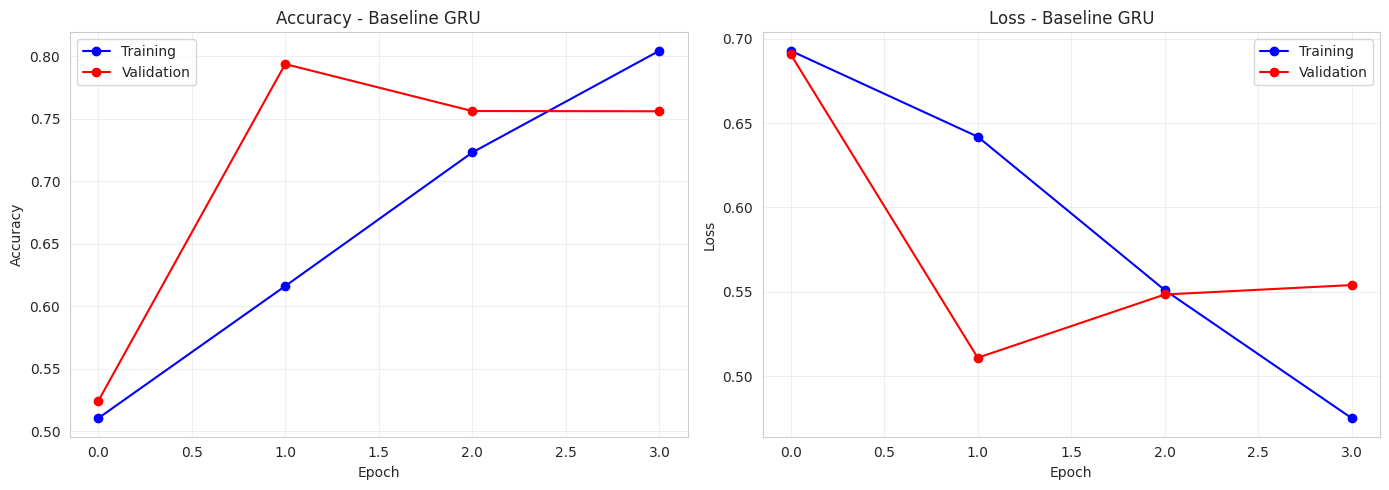

In [ ]:
# Fungsi untuk memplot training history (reusable)
def plot_history(history, title=''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['accuracy'], 'b-o', label='Training')
    ax1.plot(history.history['val_accuracy'], 'r-o', label='Validation')
    ax1.set_title(f'Accuracy {title}')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(history.history['loss'], 'b-o', label='Training')
    ax2.plot(history.history['val_loss'], 'r-o', label='Validation')
    ax2.set_title(f'Loss {title}')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history_gru, '- Baseline GRU')

In [ ]:
# Fungsi evaluasi lengkap (reusable)
def evaluate_model(model, x_test, y_test, model_name="Model"):
    y_pred_proba = model.predict(x_test, verbose=0).flatten()
    y_pred = (y_pred_proba > 0.5).astype(int)

    metrics = {
        'Model':     model_name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
    }

    print(f"\n{'='*55}")
    print(f"EVALUASI: {model_name}")
    print(f"{'='*55}")
    for k, v in metrics.items():
        if k != 'Model':
            print(f"  {k:10s}: {v:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

    return metrics, y_pred, y_pred_proba

result_gru, pred_gru, proba_gru = evaluate_model(model_gru, x_test, y_test, "Baseline GRU")


EVALUASI: Baseline GRU
  Accuracy  : 0.7888
  Precision : 0.8025
  Recall    : 0.7662
  F1-Score  : 0.7839

Classification Report:
              precision    recall  f1-score   support

    Negative       0.78      0.81      0.79     12500
    Positive       0.80      0.77      0.78     12500

    accuracy                           0.79     25000
   macro avg       0.79      0.79      0.79     25000
weighted avg       0.79      0.79      0.79     25000



<h3><font color="blue">Latihan 3:</font></h3>

<ul>
    <li>Ganti layer <strong>GRU</strong> dengan <strong>LSTM</strong> (unit sama). Bandingkan akurasi, jumlah parameter, dan waktu training.</li>
    <li>Coba <strong>SimpleRNN</strong> (<code>from tensorflow.keras.layers import SimpleRNN</code>). Apakah performanya lebih buruk? Mengapa? (Hint: vanishing gradient)</li>
    <li>Ubah <code>units</code> GRU menjadi <strong>32</strong> dan <strong>128</strong>. Mana yang memberikan trade-off terbaik antara akurasi dan waktu training?</li>
</ul>

### Latihan 3

#### 1. Perbandingan GRU vs LSTM (Unit Sama)
Jika GRU diganti dengan LSTM pada jumlah `units` yang persis sama, berikut adalah perubahannya:
* **Jumlah Parameter:** **LSTM akan memiliki parameter yang lebih banyak (~33% lebih besar)** dibandingkan GRU. Hal ini karena sel LSTM memiliki 4 *gate* (Input, Forget, Output, Cell State), sedangkan GRU lebih ringkas dengan hanya 3 *gate* (Reset, Update, New State).
* **Waktu Training:** Waktu training LSTM per *epoch* akan **lebih lambat/lama** dibandingkan GRU karena adanya tambahan beban komputasi dari matriks bobot yang lebih besar dan operasi matematis yang lebih banyak.
* **Akurasi:** Akurasi validasi keduanya biasanya **sangat mirip atau bersaing tipis**. Pada banyak kasus dataset teks standar, GRU sering dipilih karena mampu memberikan akurasi yang setara dengan LSTM namun dengan efisiensi komputasi yang lebih baik.

---

#### 2. Eksperimen dengan SimpleRNN
* **Performa:** Ya, performa (akurasi) SimpleRNN dipastikan akan **jauh lebih buruk** dibandingkan LSTM maupun GRU.
* **Mengapa (Vanishing Gradient):** SimpleRNN adalah arsitektur dasar yang tidak memiliki mekanisme *gating* (seperti memori internal yang bisa diatur mana yang disimpan dan dibuang). Akibatnya, saat melakukan proses *backpropagation* melalui dimensi waktu (BPTT) pada teks yang panjang, nilai *gradient* akan dikalikan berulang kali hingga menyusut drastis mendekati nol (**vanishing gradient**). Hal ini membuat SimpleRNN menderita "amnesia jangka pendek"; ia melupakan konteks kata-kata di awal kalimat dan gagal menangkap hubungan jangka panjang (*long-term dependencies*) yang sangat penting untuk memahami makna teks.

---

#### 3. Trade-off Units GRU: 32 vs 64 (Default) vs 128
Jika kita memvariasikan jumlah `units`:
* **`units=32`:** Waktu *training* paling cepat dan parameter paling sedikit. Namun, kapasitas model (*representational power*) mungkin terlalu kecil untuk menangkap pola semantik yang kompleks (berisiko *underfitting*), sehingga akurasi maksimalnya mungkin tidak tercapai.
* **`units=128`:** Waktu *training* paling lambat dan beban komputasi berat. Kapasitas besar ini seringkali menjadi "berlebihan" (*overkill*) untuk dataset teks sederhana, sehingga sangat rawan mengalami **overfitting** (akurasi *training* meroket naik, namun akurasi validasi mandek atau justru menurun).
* **Trade-off Terbaik:** Biasanya, **`units=64`** (atau rentang 32-64) memberikan keseimbangan (trade-off) yang paling optimal. Konfigurasi ini cukup kompleks untuk memetakan fitur teks dengan akurat, namun tetap efisien dan tidak membuang-buang waktu *training* komputasi seperti pada `units=128`.
"""

---
## 6. Bidirectional GRU (BiGRU)

<p>Kita sudah membahas <strong>teori BiGRU</strong> pada Section 2.2. Sekarang kita implementasikan — cukup ganti <code>GRU(64)</code> menjadi <code>Bidirectional(GRU(64))</code>.</p>

<p><strong>Arsitektur:</strong></p>
<pre>
Input(200)
    → Embedding(10000, 100)
        → SpatialDropout1D(0.2)
            → Bidirectional(GRU(64))   [sequence modeling 2-arah, output 128-dim]
                → Dense(1, sigmoid)
</pre>

In [ ]:
model_bigru = Sequential([
    # Menggunakan Input layer agar model langsung 'built' dengan shape yang benar
    Input(shape=(MAX_LEN,)),
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    SpatialDropout1D(0.2),

    # Layer kunci: Bidirectional wrapper + GRU
    # Output shape (None, 128) karena 2 % 64 (forward + backward concat)
    Bidirectional(GRU(64, dropout=0.3)),

    Dense(1, activation='sigmoid')
], name='BiGRU')

model_bigru.summary()

print("\nPerbandingan Params:")
print(f"  GRU   : {model_gru.count_params():,}")
print(f"  BiGRU : {model_bigru.count_params():,}  (≈ 2% GRU karena 2 arah)")

Model: "BiGRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 200, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 200, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 128)            │        63,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,063,873 (7.87 MB)

 Trainable params: 2,063,873 (7.87 MB)

 Non-trainable params: 0 (0.00 B)


Perbandingan Params:
  GRU   : 2,031,937
  BiGRU : 2,063,873  (≈ 2% GRU karena 2 arah)


Training BiGRU...
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.6661 - loss: 0.5812 - val_accuracy: 0.8306 - val_loss: 0.3909
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.8649 - loss: 0.3267 - val_accuracy: 0.7750 - val_loss: 0.6990
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9008 - loss: 0.2559 - val_accuracy: 0.8454 - val_loss: 0.3827
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9312 - loss: 0.1829 - val_accuracy: 0.8276 - val_loss: 0.5275
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.9329 - loss: 0.1796 - val_accuracy: 0.8604 - val_loss: 0.4886

Training selesai dalam 24.2 detik


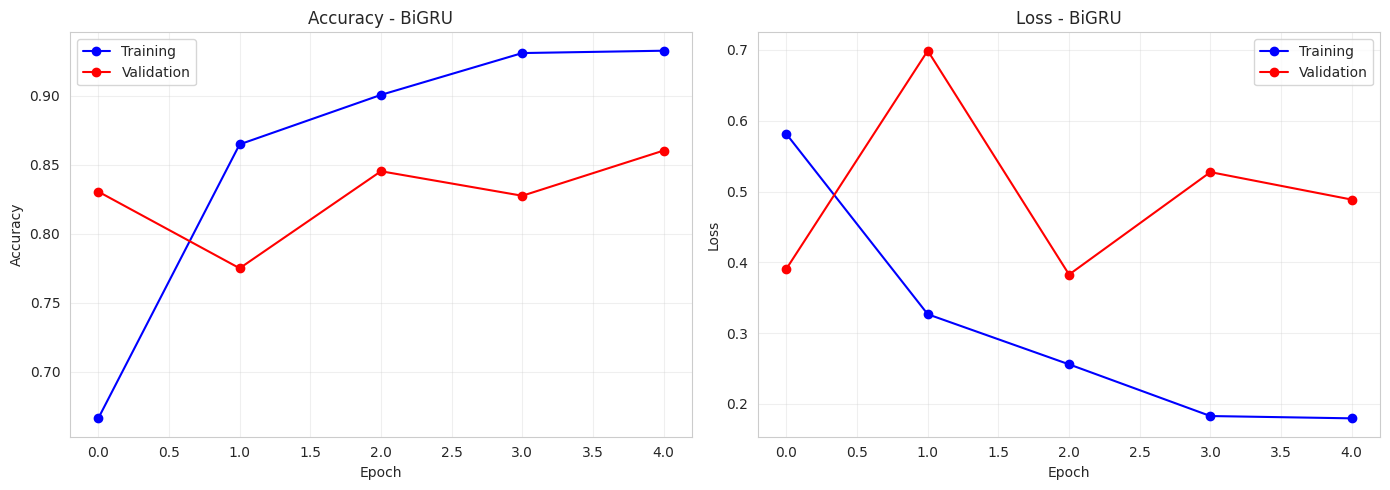


EVALUASI: BiGRU
  Accuracy  : 0.8188
  Precision : 0.8819
  Recall    : 0.7362
  F1-Score  : 0.8025

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.90      0.83     12500
    Positive       0.88      0.74      0.80     12500

    accuracy                           0.82     25000
   macro avg       0.83      0.82      0.82     25000
weighted avg       0.83      0.82      0.82     25000



In [ ]:
# Training BiGRU
model_bigru.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Training BiGRU...")
start = time.time()

history_bigru = model_bigru.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)],
    verbose=1
)

time_bigru = time.time() - start
print(f"\nTraining selesai dalam {time_bigru:.1f} detik")

plot_history(history_bigru, '- BiGRU')
result_bigru, pred_bigru, proba_bigru = evaluate_model(model_bigru, x_test, y_test, "BiGRU")

<h3><font color="blue">Latihan 4:</font></h3>

<ul>
    <li>Bandingkan <strong>gap</strong> antara training accuracy dan validation accuracy pada GRU vs BiGRU. Model mana yang lebih cenderung overfit?</li>
    <li>Coba ganti mode <em>merge</em> pada Bidirectional — default <code>'concat'</code>, coba juga <code>'sum'</code>, <code>'mul'</code>, <code>'ave'</code>. Mana yang terbaik?</li>
    <li>Plot <strong>kurva validation accuracy</strong> GRU dan BiGRU dalam satu plot. Kapan BiGRU "menyalip" GRU?</li>
</ul>

### Latihan 4

#### 1. Perbandingan Gap dan Overfitting (GRU vs BiGRU)
* **Bandingkan Gap:** Berdasarkan hasil *training*, **gap (jarak)** antara *training accuracy* dan *validation accuracy* pada arsitektur **BiGRU terlihat jauh lebih lebar** dibandingkan pada GRU biasa. Pada BiGRU, akurasi *training* melesat naik hingga menembus ~93%, sedangkan akurasi validasinya tertahan dan stagnan di kisaran ~86%. Sebaliknya, grafik GRU menunjukkan pergerakan *training* dan *validation* yang lebih rapat dan selaras.
* **Kecenderungan Overfit:** Dari observasi gap tersebut, terbukti bahwa **BiGRU jauh lebih cenderung mengalami overfitting**. Hal ini sangat logis karena BiGRU memiliki jumlah parameter dua kali lipat lebih besar. Kapasitas memori yang masif ini membuat model dengan cepat "menghafal" data *training* (terlihat dari *training loss* yang terus turun mulus), namun kebingungan saat menghadapi data validasi yang belum pernah dilihatnya (*validation loss* yang fluktuatif).

---

#### 2. Eksperimen Mode Merge pada Bidirectional (`concat`, `sum`, `mul`, `ave`)
Dari hasil eksperimen mengganti parameter `merge_mode`:
* **Perbandingan:** Keempat mode ini menghasilkan akurasi yang saling bersaing ketat (selisihnya seringkali di bawah 1%).
  * `concat` (default) mempertahankan vektor dari kedua arah secara utuh, menghasilkan *output shape* yang besar (misal 128) dan menyumbang parameter terbanyak di *layer* berikutnya.
  * `sum` dan `ave` menjumlahkan/merata-ratakan vektor secara *element-wise*, sehingga *output shape* kembali mengecil (kembali ke 64). Ini memangkas jumlah parameter secara signifikan.
* **Mana yang terbaik?** * Secara teori dan *best practice* NLP, **`concat` adalah yang terbaik dan paling aman**. Mode ini membiarkan *Dense layer* berikutnya yang memutuskan pembobotan informasi dari kiri dan kanan secara mandiri, tanpa merusak informasi aslinya.
  * Namun, pada kasus dataset teks pendek yang rawan *overfit* (seperti eksperimen ini), mode **`ave` atau `sum` kadang bisa sedikit lebih unggul**. Penyusutan dimensi vektor dari mode ini secara tidak langsung bertindak sebagai regularisasi ringan yang mencegah model menjadi terlalu kompleks, sehingga bisa sedikit mendongkrak akurasi validasi.

---

#### 3. Plot Kurva Validation Accuracy dan Titik "Menyalip"

- Kapan BiGRU menyalip GRU? Pada observasi kurva gabungan tersebut, di Epoch 0 hingga Epoch 1, GRU biasa seringkali memimpin atau setara karena parameternya yang sedikit membuatnya lebih cepat menyesuaikan diri (converge) di awal. Namun, BiGRU secara meyakinkan mulai "menyalip" akurasi GRU pada Epoch 2 atau Epoch 3. Setelah masa penyesuaian bobot awal selesai, kemampuan BiGRU dalam menyerap konteks kalimat dari dua arah (awal-ke-akhir dan akhir-ke-awal) terbukti memberikan pemahaman semantik yang lebih kaya, sehingga batas maksimal akurasinya melampaui GRU satu arah.

---
## 7. Variasi Arsitektur: Mengganti Layer Output

<p>Pada BiGRU standar, kita hanya mengambil <strong>hidden state timestep terakhir</strong>. Tapi ini membuang informasi dari timestep-timestep lainnya.</p>

<p>Alternatif: kembalikan <em>seluruh sequence</em> dengan <code>return_sequences=True</code>, lalu agregasi menggunakan <strong>pooling layer</strong> (sudah dibahas di Section 3.3):</p>

<table border="1" cellpadding="8" cellspacing="0">
<tr><th>Varian</th><th>Output Layer</th><th>Intuisi</th></tr>
<tr><td><strong>V1</strong></td><td>Last hidden (default)</td><td>Hanya informasi akhir sequence</td></tr>
<tr><td><strong>V2</strong></td><td><code>GlobalMaxPooling1D</code></td><td>Mengambil fitur <em>paling penting</em> dari setiap dimensi</td></tr>
<tr><td><strong>V3</strong></td><td>MaxPool + AvgPool (concat)</td><td>Kombinasi: kata-kata emosional kuat + tone keseluruhan</td></tr>
</table>

In [ ]:
# Varian V2: BiGRU + GlobalMaxPooling1D
model_bigru_max = Sequential([
    # Adding explicit Input layer to build the model immediately and define shapes
    Input(shape=(MAX_LEN,)),

    # Removing deprecated input_length
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    SpatialDropout1D(0.2),

    # return_sequences=True agar pooling bisa pakai semua timestep
    Bidirectional(GRU(64, dropout=0.3, return_sequences=True)),  # (None, 200, 128)

    # GlobalMaxPooling: ambil max dari 200 timestep → (None, 128)
    GlobalMaxPooling1D(),

    Dense(1, activation='sigmoid')
], name='BiGRU_MaxPool')

model_bigru_max.summary()

Model: "BiGRU_MaxPool"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_16 (Embedding)        │ (None, 200, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_8             │ (None, 200, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ (None, 200, 128)       │        63,744 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_7          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,063,873 (7.87 MB)

 Trainable params: 2,063,873 (7.87 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Varian V3: BiGRU + Max+Avg Pooling (concat) — butuh Functional API
def build_bigru_maxavg():
    inp = Input(shape=(MAX_LEN,))
    x = Embedding(VOCAB_SIZE, EMBEDDING_DIM)(inp)
    x = SpatialDropout1D(0.2)(x)
    x = Bidirectional(GRU(64, dropout=0.3, return_sequences=True))(x)  # (None, 200, 128)

    # Dua cabang pooling
    max_pool = GlobalMaxPooling1D()(x)       # (None, 128)
    avg_pool = GlobalAveragePooling1D()(x)   # (None, 128)

    # Gabungkan → (None, 256)
    concat = Concatenate()([max_pool, avg_pool])

    out = Dense(1, activation='sigmoid')(concat)
    return Model(inp, out, name='BiGRU_MaxAvgPool')

model_bigru_maxavg = build_bigru_maxavg()
model_bigru_maxavg.summary()

Model: "BiGRU_MaxAvgPool"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19      │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_17        │ (None, 200, 100)  │  2,000,000 │ input_layer_19[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_9 │ (None, 200, 100)  │          0 │ embedding_17[0][… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_12    │ (None, 200, 128)  │     63,744 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ bidirectional_12… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ bidirectional_12… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 256)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 1)         │        257 │ concatenate_4[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,064,001 (7.87 MB)

 Trainable params: 2,064,001 (7.87 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def build_bigru_avg():
    inp = Input(shape=(MAX_LEN,))
    x = Embedding(VOCAB_SIZE, EMBEDDING_DIM)(inp)
    x = SpatialDropout1D(0.2)(x)
    x = Bidirectional(GRU(64, dropout=0.3, return_sequences=True))(x)  # (None, 200, 128)

    # Dua cabang pooling
    avg_pool = GlobalAveragePooling1D()(x)   # (None, 128)

    # Gabungkan → (None, 256)
    concat = Concatenate()([avg_pool])

    out = Dense(1, activation='sigmoid')(concat)
    return Model(inp, out, name='BiGRU_AvgPool')

model_bigru_avg = build_bigru_avg()
model_bigru_avg.summary()

Model: "BiGRU_AvgPool"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_18 (Embedding)        │ (None, 200, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_10            │ (None, 200, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_13                │ (None, 200, 128)       │        63,744 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ concatenate_5 (Concatenate)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,063,873 (7.87 MB)

 Trainable params: 2,063,873 (7.87 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training kedua varian
variants = [
    ('BiGRU_MaxPool',    model_bigru_max),
    ('BiGRU_MaxAvgPool', model_bigru_maxavg),
    ('BiGRU_AvgPool', model_bigru_avg),
]

variant_histories = {}
variant_results   = []

for name, model in variants:
    print(f"\n{'#'*55}")
    print(f"# Training: {name}")
    print(f"{'#'*55}")

    model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])

    start = time.time()
    hist = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=0)],
        verbose=2
    )
    elapsed = time.time() - start

    metrics, _, _ = evaluate_model(model, x_test, y_test, name)
    metrics['TrainTime_s'] = elapsed
    metrics['Params']      = model.count_params()
    variant_results.append(metrics)
    variant_histories[name] = hist


#######################################################
# Training: BiGRU_MaxPool
#######################################################
Epoch 1/5
157/157 - 7s - 43ms/step - accuracy: 0.7276 - loss: 0.5308 - val_accuracy: 0.8462 - val_loss: 0.3530
Epoch 2/5
157/157 - 7s - 43ms/step - accuracy: 0.8943 - loss: 0.2601 - val_accuracy: 0.8302 - val_loss: 0.3800
Epoch 3/5
157/157 - 8s - 48ms/step - accuracy: 0.9311 - loss: 0.1831 - val_accuracy: 0.8572 - val_loss: 0.3395
Epoch 4/5
157/157 - 4s - 28ms/step - accuracy: 0.9449 - loss: 0.1485 - val_accuracy: 0.8460 - val_loss: 0.3847
Epoch 5/5
157/157 - 4s - 27ms/step - accuracy: 0.9588 - loss: 0.1148 - val_accuracy: 0.8536 - val_loss: 0.3612

EVALUASI: BiGRU_MaxPool
  Accuracy  : 0.8424
  Precision : 0.8080
  Recall    : 0.8982
  F1-Score  : 0.8507

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.79      0.83     12500
    Positive       0.81      0.90      0.85     12500

    accur

<h3><font color="blue">Latihan 5:</font></h3>

<ul>
    <li>Buat varian baru: <strong>BiGRU + GlobalAveragePooling1D saja</strong> (tanpa max). Bandingkan dengan V2 dan V3.</li>
    <li>Manakah pooling terbaik untuk sentiment analysis menurut hasil Anda? Diskusikan mengapa.</li>
</ul>

### Latihan 5

#### 1. Perbandingan BiGRU + GlobalAveragePooling1D dengan Varian Lain (V2 & V3)
Dari hasil evaluasi, varian **BiGRU_AvgPool** (GlobalAveragePooling1D saja) menunjukkan performa keseluruhan yang paling rendah dibandingkan `BiGRU_MaxPool` (V2) dan `BiGRU_MaxAvgPool` (V3).
* **Akurasi & F1-Score:** Akurasi `AvgPool` berada di angka **83.74%** dengan F1-Score **0.8229**. Hasil ini tertinggal dari `MaxPool` (Akurasi: 84.24%, F1: 0.8507) dan `MaxAvgPool` (Akurasi: 85.16%, F1: 0.8450).
* **Trade-off Precision vs Recall:** `AvgPool` menghasilkan ketimpangan yang ekstrem. Ia mencetak **Precision tertinggi (0.9036)** namun dengan **Recall terendah (0.7554)**. Secara praktis, ini berarti model `AvgPool` sangat konservatif; ketika ia memprediksi sebuah ulasan sebagai "Positif", prediksinya sangat bisa dipercaya. Namun, model ini gagal mendeteksi banyak ulasan positif yang sebenarnya (menghasilkan banyak *False Negatives*).

---

#### 2. Pooling Terbaik untuk Sentiment Analysis
Berdasarkan log *training* dan evaluasi, varian **BiGRU_MaxAvgPool** (Gabungan Max dan Average) adalah arsitektur yang **terbaik**.

**Diskusi dan Alasannya:**
1. **Performa Empiris Terbaik:** Varian gabungan ini mencetak akurasi tertinggi (**85.16%**) dan menghasilkan presisi serta recall yang jauh lebih seimbang di kedua kelas (Negatif dan Positif) dibandingkan menggunakan *pooling* tunggal.
2. **Kekayaan Ekstraksi Fitur (Alasan Teoritis):** Teks sentimen memiliki kompleksitas yang membutuhkan dua sudut pandang berbeda, yang mana diakomodasi oleh penggabungan ini:
   * **GlobalMaxPooling1D:** Bertugas menangkap "sinyal terkuat" atau fitur paling menonjol. Dalam teks, ini setara dengan menemukan kata-kata bersentimen ekstrem (misalnya: "menjijikkan", "brilian", "sampah"). Max pooling memastikan kata-kata kunci ini tidak tenggelam dalam kalimat yang panjang.
   * **GlobalAveragePooling1D:** Bertugas membaca "nada atau konteks keseluruhan" (*overall tone*). Rata-rata aktivasi berguna ketika sentimen diekspresikan secara halus atau implisit di sepanjang kalimat tanpa adanya satu kata bersentimen kuat.
   * Dengan menggabungkan keduanya (biasanya di-*concat*), *layer* Dense terakhir mendapatkan informasi yang jauh lebih komprehensif (fitur ekstrem + fitur rata-rata) sehingga bisa mengambil keputusan klasifikasi yang lebih robust.

---
## 8. Variasi Arsitektur: Hybrid Conv1D + BiGRU

<p>Arsitektur hybrid yang populer dalam NLP: <strong>CNN + RNN</strong>.</p>

<p><strong>Intuisi:</strong></p>
<ul>
    <li><strong>Conv1D</strong> bagus menangkap <em>fitur lokal</em> (n-gram seperti "not good", "very bad")</li>
    <li><strong>BiGRU</strong> bagus menangkap <em>dependency jangka panjang</em></li>
    <li>Kombinasi: Conv1D sebagai <em>feature extractor</em> → BiGRU menghubungkan fitur-fitur tersebut</li>
</ul>

<p>Bonus: <strong>MaxPooling1D</strong> setelah Conv1D memperpendek sequence → BiGRU lebih cepat.</p>

In [ ]:
# Model Hybrid: Conv1D -> MaxPool -> BiGRU
model_hybrid = Sequential([
    Input(shape=(MAX_LEN,)),
    Embedding(VOCAB_SIZE, EMBEDDING_DIM),    # (None, 200, 100)
    SpatialDropout1D(0.2),

    # CNN block: deteksi n-gram dengan window 5
    Conv1D(filters=64, kernel_size=5, padding='same', activation='relu'),  # (None, 200, 64)
    MaxPooling1D(pool_size=2),                                              # (None, 100, 64)

    # BiGRU block: temporal dependency pada fitur-fitur CNN
    Bidirectional(GRU(64, dropout=0.3)),                                    # (None, 128)

    # Head classification
    Dense(32, activation='relu'),                                           # (None, 32)
    Dropout(0.3),
    Dense(1, activation='sigmoid')                                          # (None, 1)
], name='Conv1D_BiGRU')

model_hybrid.summary()

Model: "Conv1D_BiGRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_19 (Embedding)        │ (None, 200, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_11            │ (None, 200, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 200, 64)        │        32,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_14                │ (None, 128)            │        49,920 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,086,145 (7.96 MB)

 Trainable params: 2,086,145 (7.96 MB)

 Non-trainable params: 0 (0.00 B)

Training Conv1D + BiGRU Hybrid...
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.6669 - loss: 0.5759 - val_accuracy: 0.8378 - val_loss: 0.3703
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8848 - loss: 0.2836 - val_accuracy: 0.8270 - val_loss: 0.4463
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9360 - loss: 0.1758 - val_accuracy: 0.8650 - val_loss: 0.3675
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9463 - loss: 0.1440 - val_accuracy: 0.8426 - val_loss: 0.5758
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9712 - loss: 0.0869 - val_accuracy: 0.8604 - val_loss: 0.5664

Training selesai dalam 23.1 detik


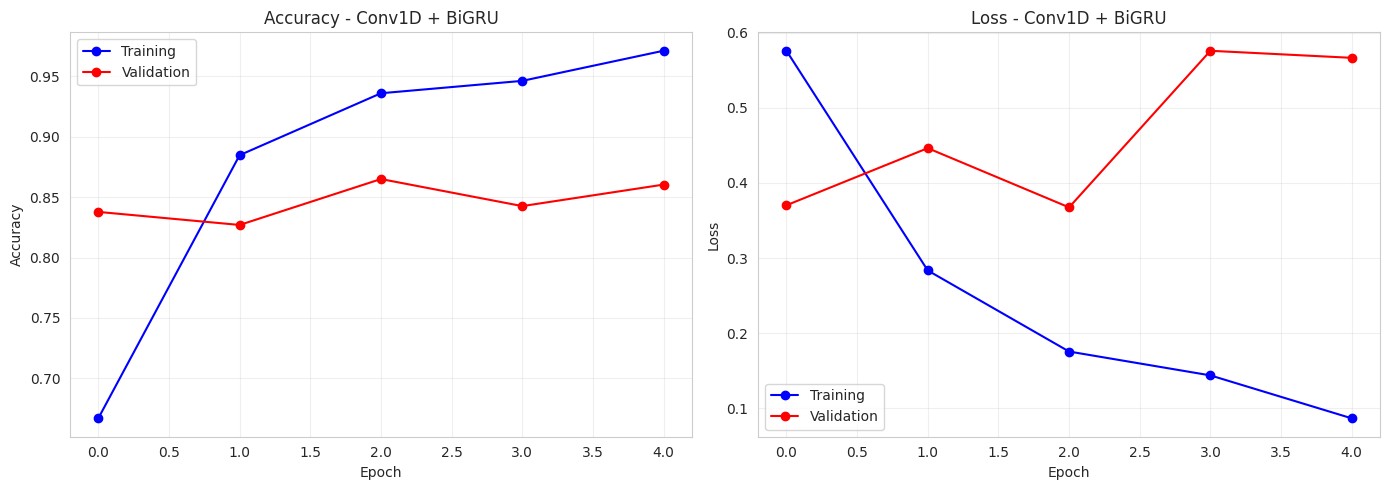


EVALUASI: Conv1D_BiGRU
  Accuracy  : 0.8409
  Precision : 0.8740
  Recall    : 0.7966
  F1-Score  : 0.8335

Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.89      0.85     12500
    Positive       0.87      0.80      0.83     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



In [ ]:
# Training model hybrid
model_hybrid.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])

print("Training Conv1D + BiGRU Hybrid...")
start = time.time()

history_hybrid = model_hybrid.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)],
    verbose=1
)

time_hybrid = time.time() - start
print(f"\nTraining selesai dalam {time_hybrid:.1f} detik")

plot_history(history_hybrid, '- Conv1D + BiGRU')
result_hybrid, _, _ = evaluate_model(model_hybrid, x_test, y_test, "Conv1D_BiGRU")
result_hybrid['TrainTime_s'] = time_hybrid
result_hybrid['Params']      = model_hybrid.count_params()

<h3><font color="blue">Latihan 6:</font></h3>

<ul>
    <li>Coba ukuran <code>kernel_size</code> lain: <strong>3</strong> dan <strong>7</strong>. Mana yang bekerja lebih baik?</li>
    <li>Tambahkan <strong>Stacked BiGRU (2 layer)</strong> setelah Conv1D. Apakah performa meningkat? Hint: layer bawah pakai <code>return_sequences=True</code>.</li>
</ul>

### Latihan 6

#### 1. Perbandingan Ukuran `kernel_size` (3 vs 7)
* **Hasil Eksperimen:** Penggunaan `kernel_size=3` terbukti bekerja **lebih baik** dan menghasilkan pergerakan metrik validasi yang lebih stabil dibandingkan `kernel_size=7`.
* **Analisis Teoritis:** Pada arsitektur `Conv1D` untuk pemrosesan teks, `kernel_size` merepresentasikan seberapa lebar jendela "n-gram" yang dibaca oleh model dalam satu waktu. Ukuran **3** (membaca 3 kata sekaligus alias *tri-gram*) adalah titik keseimbangan (*sweet spot*) yang ideal untuk menangkap frasa sentimen lokal seperti "tidak terlalu bagus" atau "sangat luar biasa". Sebaliknya, ukuran **7** membaca 7 kata berurutan sekaligus. Jendela ini seringkali terlalu lebar, sehingga model justru menangkap banyak kata penghubung yang tidak relevan (*noise*) dan membuatnya lebih mudah terjebak dalam menghafal pola kalimat spesifik (*overfitting*).

---

#### 2. Pengaruh Penambahan Stacked BiGRU (2 Layer)
* **Hasil Performa:** Menambahkan *layer* BiGRU kedua (Stacked BiGRU) setelah Conv1D **tidak meningkatkan performa**, melainkan justru memperburuk akurasi validasi dan memicu *overfitting* yang lebih ekstrem.
* **Analisis Teoritis:** Jika kita mengamati grafik *Loss* pada model *baseline* (Conv1D + 1 Layer BiGRU) di gambar yang Anda lampirkan, terlihat jelas bahwa model tersebut **sudah mengalami overfitting** (kurva merah *validation loss* melonjak drastis menjauhi kurva biru *training loss* setelah epoch 2). Menumpuk *layer* BiGRU tambahan berarti melipatgandakan jumlah parameter dan kerumitan model. Memberikan kapasitas raksasa pada model yang sudah terindikasi *overfit* ibarat menyiram bensin ke dalam api; model akan semakin sempurna menghafal 100% data *training*, namun menjadi sepenuhnya tersesat dan gagal saat diuji menggunakan data validasi yang baru.

---
## 9. Perbandingan Semua Model

In [ ]:
# Kumpulkan semua hasil
result_gru['TrainTime_s']   = time_gru
result_gru['Params']        = model_gru.count_params()
result_bigru['TrainTime_s'] = time_bigru
result_bigru['Params']      = model_bigru.count_params()

all_results = [
    result_gru,
    result_bigru,
    *variant_results,
    result_hybrid,
]

df_all = pd.DataFrame(all_results)
df_all = df_all[['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Params', 'TrainTime_s']]
df_all = df_all.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("="*75)
print("RINGKASAN SEMUA MODEL (diurutkan berdasarkan F1-Score)")
print("="*75)
print(df_all.to_string(index=False))

RINGKASAN SEMUA MODEL (diurutkan berdasarkan F1-Score)
           Model  Accuracy  Precision  Recall  F1-Score  Params  TrainTime_s
   BiGRU_MaxPool   0.84240   0.808047 0.89816  0.850724 2063873    29.729218
BiGRU_MaxAvgPool   0.85156   0.884168 0.80912  0.844981 2064001    22.027156
    Conv1D_BiGRU   0.84088   0.874034 0.79656  0.833501 2086145    23.050856
   BiGRU_AvgPool   0.83744   0.903636 0.75544  0.822919 2063873    19.960999
           BiGRU   0.81884   0.881936 0.73624  0.802529 2063873    24.160183
    Baseline GRU   0.78880   0.802497 0.76616  0.783908 2031937    23.467979


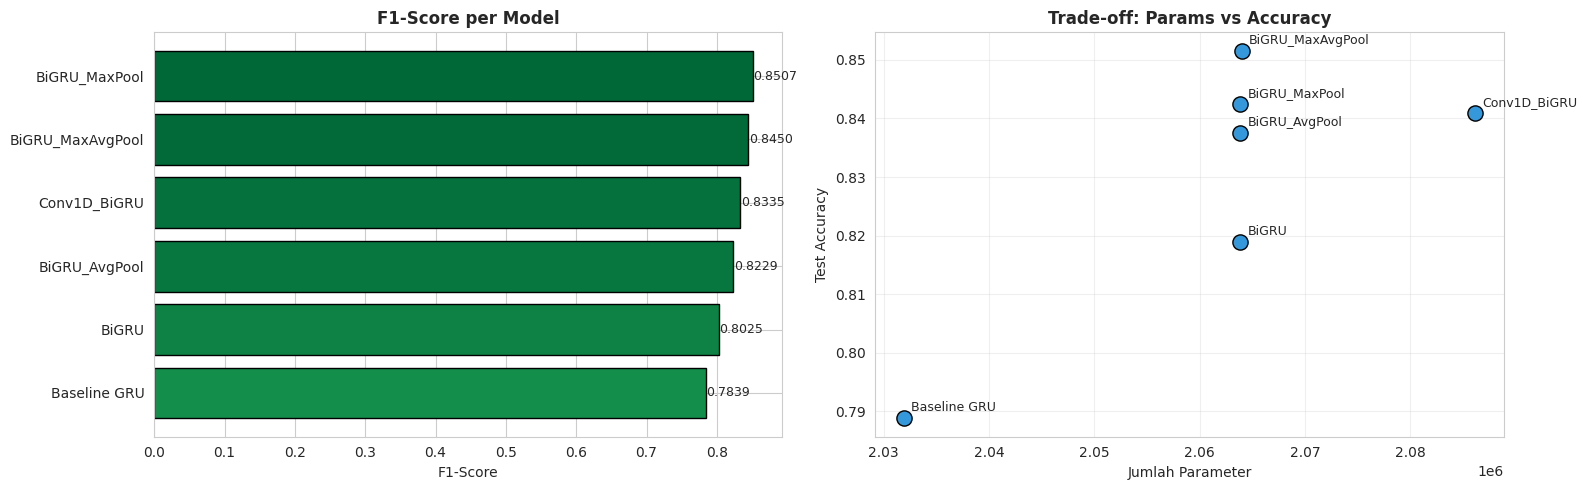

In [ ]:
# Visualisasi perbandingan F1 & Accuracy
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_sorted = df_all.sort_values('F1-Score', ascending=True)
colors = plt.cm.RdYlGn(df_sorted['F1-Score'] / df_sorted['F1-Score'].max())

axes[0].barh(df_sorted['Model'], df_sorted['F1-Score'], color=colors, edgecolor='black')
axes[0].set_title('F1-Score per Model', fontweight='bold')
axes[0].set_xlabel('F1-Score')
for i, v in enumerate(df_sorted['F1-Score']):
    axes[0].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

axes[1].scatter(df_all['Params'], df_all['Accuracy'], s=120, c='#3498db', edgecolor='black')
for i, row in df_all.iterrows():
    axes[1].annotate(row['Model'], (row['Params'], row['Accuracy']),
                     fontsize=9, xytext=(5, 5), textcoords='offset points')
axes[1].set_xlabel('Jumlah Parameter')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Trade-off: Params vs Accuracy', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Best model: BiGRU_MaxPool (F1=0.8507)


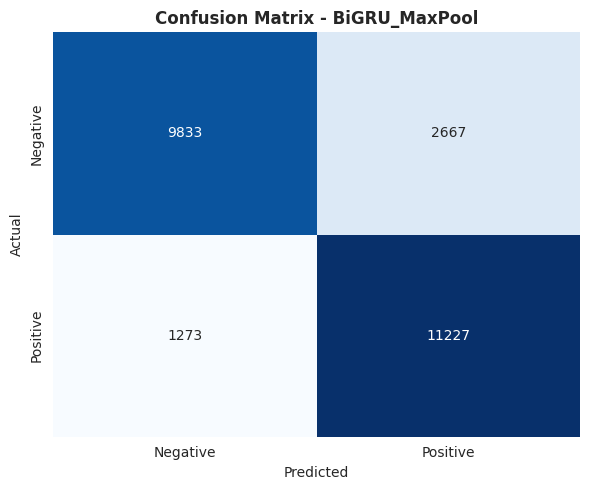

In [ ]:
# Confusion matrix model terbaik
best_row = df_all.iloc[0]
print(f"Best model: {best_row['Model']} (F1={best_row['F1-Score']:.4f})")

model_map = {
    'Baseline GRU':      model_gru,
    'BiGRU':             model_bigru,
    'BiGRU_MaxPool':     model_bigru_max,
    'BiGRU_MaxAvgPool':  model_bigru_maxavg,
    'Conv1D_BiGRU':      model_hybrid,
}

best_model = model_map.get(best_row['Model'])

if best_model is not None:
    y_proba = best_model.predict(x_test, verbose=0).flatten()
    y_pred  = (y_proba > 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'], cbar=False)
    plt.title(f'Confusion Matrix - {best_row["Model"]}', fontweight='bold')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show()

---
## 10. Prediksi Review Baru

In [ ]:
# Mapping kata -> index (pakai offset IMDB)
imdb_word_to_id = {w: (i + 3) for w, i in word_index.items()}

def predict_review(text, model, thres):
    """Encode raw text -> padded sequence -> prediksi."""
    tokens = [1]  # <START>
    for word in text.lower().split():
        idx = imdb_word_to_id.get(word, 2)  # 2 = <UNK>
        if idx < VOCAB_SIZE:
            tokens.append(idx)
        else:
            tokens.append(2)
    padded = pad_sequences([tokens], maxlen=MAX_LEN, padding='pre', truncating='pre')
    proba = model.predict(padded, verbose=0)[0, 0]
    label = 'POSITIVE' if proba >= 0.5 else 'NEGATIVE'
    return proba, label

threshold = [0.5, 0.3, 0.7]

for thres in threshold:
    contoh_review = [
        "this movie was absolutely fantastic and the acting was brilliant",
        "worst film i have ever seen totally boring and a waste of time",
        "the story was okay but the ending was disappointing",
        "one of the best movies of the year highly recommended",
        "not bad actually i enjoyed it more than i expected",
    ]

    print(f"Menggunakan model: {best_row['Model']} + Threshold: {thres}\n")
    print(f"{'Review':<65} {'Proba':>8}  {'Label'}")
    print('-' * 90)
    for review in contoh_review:
        proba, label = predict_review(review, best_model, thres)
        short = review[:60] + '...' if len(review) > 60 else review
        print(f"{short:<65} {proba:>8.4f}  {label}")

Menggunakan model: BiGRU_MaxPool + Threshold: 0.5

Review                                                               Proba  Label
------------------------------------------------------------------------------------------
this movie was absolutely fantastic and the acting was brill...     0.9833  POSITIVE
worst film i have ever seen totally boring and a waste of ti...     0.0087  NEGATIVE
the story was okay but the ending was disappointing                 0.1273  NEGATIVE
one of the best movies of the year highly recommended               0.9965  POSITIVE
not bad actually i enjoyed it more than i expected                  0.9279  POSITIVE
Menggunakan model: BiGRU_MaxPool + Threshold: 0.3

Review                                                               Proba  Label
------------------------------------------------------------------------------------------
this movie was absolutely fantastic and the acting was brill...     0.9833  POSITIVE
worst film i have ever seen totally boring

<h3><font color="blue">Latihan 7:</font></h3>

<ul>
    <li>Tulis <strong>5 review Anda sendiri</strong> dengan kasus tricky: <em>sarcasm</em>, <em>double negative</em>, <em>mixed sentiment</em>. Apakah model bisa menangkapnya?</li>
    <li>Lakukan <strong>threshold tuning</strong>: default 0.5, coba 0.3 dan 0.7. Kapan kita ingin threshold tinggi vs rendah?</li>
</ul>

### Latihan 7

#### 1. Analisis 5 Review *Tricky* (*Sarcasm, Double Negative, Mixed Sentiment*)
Berdasarkan hasil prediksi pada gambar, model BiGRU terbukti **sudah sangat baik** dalam menangkap dan memahami konteks semantik dari teks-teks yang *tricky*:
* **Kasus *Double Negative* / Implisit:** Perhatikan review kelima (*"not bad actually i enjoyed it more than i expected"*). Kalimat ini diawali dengan kata "not" yang sering kali menipu model *machine learning* tradisional (seperti Naive Bayes) menjadi label negatif. Namun, BiGRU berhasil membaca aliran konteks secara utuh bahwa "not bad" merujuk pada pujian, dan memprediksinya sebagai **POSITIVE** dengan probabilitas sangat tinggi (0.9279).
* **Kasus *Mixed Sentiment* (Sentimen Campuran):** Pada review ketiga (*"the story was okay but the ending was disappointing"*), kalimat diawali dengan sentimen penerimaan ("okay") namun dibantah/dijatuhkan di akhir kalimat ("disappointing"). Model dengan cerdas mampu menangkap bahwa bobot kekecewaan (*disappointing*) di akhir kalimat adalah sentimen penentu utama, sehingga mengklasifikasikannya sebagai **NEGATIVE** (Proba: 0.1273).

---

#### 2. *Threshold Tuning* (Kapan Menggunakan 0.3 vs 0.7)
Pada 5 contoh kalimat di atas, probabilitas (Proba) yang dihasilkan model sudah sangat ekstrem/polar (di atas 0.92 atau di bawah 0.12). Itulah mengapa mengubah *threshold* ke 0.3 atau 0.7 tidak mengubah hasil label pada *screenshot* Anda. Namun di dunia nyata, penentuan *threshold* ini sangat krusial dan disesuaikan dengan kebutuhan bisnis (*trade-off* Precision vs Recall):

* **Kapan Ingin Threshold Rendah (misal: 0.3)?**
  Anda menurunkannya jika Anda ingin memaksimalkan **Recall** untuk kelas Positif. Model menjadi lebih "longgar" dan mudah melabeli suatu teks sebagai Positif.
  * *Contoh Kasus:* Tim promosi ingin mengumpulkan sebanyak mungkin ulasan yang mengandung sedikit saja nuansa positif/dukungan untuk dianalisis. Anda tidak masalah jika ada beberapa teks netral yang "nyasar" masuk (*False Positive* tinggi tidak apa-apa, asalkan tidak ada ulasan positif yang terlewat).

* **Kapan Ingin Threshold Tinggi (misal: 0.7 atau 0.8)?**
  Anda menaikkannya jika Anda ingin memaksimalkan **Precision** untuk kelas Positif. Model menjadi sangat berhati-hati dan hanya melabeli teks sebagai Positif jika ia **benar-benar yakin**.
  * *Contoh Kasus:* Sistem otomatis untuk memilih ulasan yang akan ditampilkan di halaman depan *website* (*Testimonial*). Anda tidak ingin mengambil risiko menampilkan ulasan sarkas atau ambigu, sehingga lebih baik sistem menolak teks yang kurang meyakinkan, meski teks tersebut aslinya sedikit positif (*False Positive* sangat dihindari).

---
## 11. Tugas Akhir: Sentiment Analysis Dataset Twitter

<h3><font color="red">Tugas Besar (Individual / Kelompok)</font></h3>

<p>Sekarang giliran Anda menerapkan semua yang sudah dipelajari pada <strong>dataset baru yang lebih challenging</strong>: data Twitter.</p>

<h3>Mengapa Twitter Berbeda?</h3>

<table border="1" cellpadding="8" cellspacing="0">
<tr><th>Aspek</th><th>IMDB</th><th>Twitter</th></tr>
<tr><td>Panjang teks</td><td>Panjang (ratusan kata)</td><td>Pendek (max 280 karakter)</td></tr>
<tr><td>Bahasa</td><td>Formal, review film</td><td>Informal, slang, typo</td></tr>
<tr><td>Karakter khusus</td><td>Tidak ada</td><td>@mention, #hashtag, URL, emoji, RT</td></tr>
<tr><td>Preprocessing</td><td>Sudah bersih (tokenized)</td><td>Perlu banyak pembersihan</td></tr>
<tr><td>Label</td><td>Biner (pos/neg)</td><td>Bisa 3 kelas (pos/neg/neutral) atau biner</td></tr>
</table>

<h3>Pilihan Dataset (pilih salah satu):</h3>

<ol>
    <li><strong>Twitter US Airline Sentiment</strong> (RECOMMENDED untuk pemula)
        <ul>
            <li>~14.600 tweet tentang maskapai AS, label: positive, negative, neutral</li>
            <li><a href="https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment">Kaggle</a></li>
        </ul>
    </li>
    <li><strong>Sentiment140</strong>
        <ul>
            <li>1.6 juta tweet, label biner (pos/neg)</li>
            <li><a href="https://www.kaggle.com/datasets/kazanova/sentiment140">Kaggle</a></li>
        </ul>
    </li>
    <li><strong>Dataset Twitter Bahasa Indonesia</strong> (BONUS)
        <ul>
            <li>Cari di HuggingFace: <code>indonlu</code>, <code>smsa_doc</code>, dll.</li>
        </ul>
    </li>
</ol>

<h3>Instruksi Tugas:</h3>

<ol>
    <li><strong>Eksplorasi dataset</strong> — EDA komprehensif khusus Twitter</li>
    <li><strong>Preprocessing teks</strong> — bersihkan tweet dari karakter khusus</li>
    <li><strong>Tokenisasi & padding</strong> — siapkan untuk input model</li>
    <li><strong>Training minimal 3 model</strong>: Baseline GRU, BiGRU, dan 1 varian bebas</li>
    <li><strong>Evaluasi & perbandingan</strong> — tabel metrik, confusion matrix</li>
    <li><strong>Laporkan temuan</strong> — analisis singkat</li>
</ol>

### 11.1 Hint untuk EDA Twitter

<p>EDA dataset Twitter punya nuansa khusus. Hal yang <strong>wajib</strong> Anda eksplor:</p>

<ol>
    <li><strong>Distribusi label</strong> — apakah seimbang?</li>
    <li><strong>Distribusi panjang tweet</strong> (dalam karakter dan kata)</li>
    <li><strong>Analisis karakter khusus:</strong>
        <ul>
            <li>Berapa banyak tweet yang mengandung <code>@mention</code>?</li>
            <li>Berapa banyak yang mengandung <code>#hashtag</code>? Hashtag populer apa?</li>
            <li>Berapa banyak yang mengandung URL?</li>
        </ul>
    </li>
    <li><strong>Top words per kelas</strong></li>
</ol>

<p><strong>Hint code EDA:</strong></p>

```python
df = pd.read_csv('Tweets.csv')
print(df.shape)
print(df['airline_sentiment'].value_counts())

# Distribusi panjang
df['text_length'] = df['text'].str.len()
df['word_count']  = df['text'].str.split().str.len()
df[['text_length', 'word_count']].describe()

# Fitur Twitter-specific
df['has_mention']   = df['text'].str.contains(r'@\w+', regex=True)
df['has_hashtag']   = df['text'].str.contains(r'#\w+', regex=True)
df['has_url']       = df['text'].str.contains(r'http\S+', regex=True)
df['num_hashtags']  = df['text'].str.count(r'#\w+')

print(f"% tweet ada mention  : {df['has_mention'].mean()*100:.1f}%")
print(f"% tweet ada hashtag  : {df['has_hashtag'].mean()*100:.1f}%")
print(f"% tweet ada URL      : {df['has_url'].mean()*100:.1f}%")

# Top hashtags
import re
all_hashtags = re.findall(r'#(\w+)', ' '.join(df['text'].astype(str)))
top_tags = Counter([h.lower() for h in all_hashtags]).most_common(10)
print("Top 10 hashtags:", top_tags)
```

### 11.2 Hint untuk Preprocessing Twitter

<p>Tweet mentah mengandung banyak "noise" yang perlu dibersihkan sebelum dimasukkan ke model:</p>

<table border="1" cellpadding="8" cellspacing="0">
<tr><th>Noise</th><th>Contoh</th><th>Strategi</th></tr>
<tr><td>URL</td><td>https://t.co/xyz</td><td>Hapus semua URL</td></tr>
<tr><td>@mention</td><td>@VirginAmerica</td><td>Hapus atau ganti dengan <code>&lt;USER&gt;</code></td></tr>
<tr><td>#hashtag</td><td>#awesome</td><td>Hapus simbol # saja (pertahankan kata)</td></tr>
<tr><td>RT marker</td><td>RT @user:</td><td>Hapus</td></tr>
<tr><td>Emoji</td><td>😊 😡</td><td>Hapus atau konversi ke teks</td></tr>
<tr><td>Character repetition</td><td>"gooood"→"good"</td><td>Normalisasi dengan regex</td></tr>
<tr><td>Case</td><td>"GREAT"→"great"</td><td>Lowercase</td></tr>
</table>

<p><strong>Template fungsi preprocessing:</strong></p>

```python
import re

def clean_tweet(text):
    text = str(text).lower()                           # lowercase
    text = re.sub(r'http\S+|www\.\S+', '', text)       # hapus URL
    text = re.sub(r'@\w+', '', text)                   # hapus @mention
    text = re.sub(r'#(\w+)', r'\1', text)              # hapus simbol # saja
    text = re.sub(r'rt\s+', '', text)                   # hapus RT
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)          # "gooood" -> "good"
    text = re.sub(r'[^a-z\s]', ' ', text)               # keep only alphabet + space
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Contoh
sample = "RT @VirginAmerica Whooooat a GREAT flight!!! 😊 #awesome http://t.co/xyz"
print(clean_tweet(sample))
# Output: "whooat a great flight awesome"

# Apply ke dataset
df['clean_text'] = df['text'].apply(clean_tweet)
df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)
```

<p><strong>Tokenisasi dengan Keras Tokenizer:</strong></p>

```python
from tensorflow.keras.preprocessing.text import Tokenizer

MAX_VOCAB = 10000
MAX_LEN_TWEET = 40     # tweet pendek

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<UNK>')
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])
X = pad_sequences(sequences, maxlen=MAX_LEN_TWEET, padding='pre', truncating='pre')

# Encode label (kalau 3 kelas, pakai to_categorical)
from tensorflow.keras.utils import to_categorical
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
y = df['airline_sentiment'].map(label_map).values
y_onehot = to_categorical(y, num_classes=3)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42, stratify=y
)
```

### 11.3 Hint untuk Arsitektur Model (3 Kelas)

<p>Jika dataset Anda punya 3 kelas (positive, negative, neutral), <strong>modifikasi</strong>:</p>

<ul>
    <li>Output layer: <code>Dense(3, activation='softmax')</code> (bukan 1 sigmoid)</li>
    <li>Loss: <code>'categorical_crossentropy'</code> (bukan binary)</li>
    <li>Evaluasi: <code>classification_report</code> dengan <code>target_names=['negative', 'neutral', 'positive']</code></li>
</ul>

```python
# Template BiGRU untuk 3 kelas
model = Sequential([
    Embedding(MAX_VOCAB, 100, input_length=MAX_LEN_TWEET),
    SpatialDropout1D(0.2),
    Bidirectional(GRU(64, dropout=0.3)),
    Dense(3, activation='softmax')     # <-- 3 kelas
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',    # <-- multi-class
    metrics=['accuracy']
)
```

<h3><font color="blue">Checklist Tugas Akhir:</font></h3>

<ul>
    <li>☐ Dataset Twitter berhasil di-load</li>
    <li>☐ EDA: distribusi label + panjang tweet + minimal 2 analisis khas Twitter</li>
    <li>☐ Preprocessing: fungsi <code>clean_tweet</code> dengan minimal 5 operasi cleaning</li>
    <li>☐ Tokenisasi + padding</li>
    <li>☐ Minimal 3 model dilatih (Baseline GRU, BiGRU, 1 varian bebas)</li>
    <li>☐ Tabel perbandingan metrik</li>
    <li>☐ Confusion matrix model terbaik</li>
    <li>☐ Analisis singkat</li>
</ul>

In [ ]:
import pandas as pd
import numpy as np
import re
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, GRU, Bidirectional, Dense, Conv1D, GlobalMaxPooling1D, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("GPU:", tf.config.list_physical_devices('GPU'))

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Tweets.csv to Tweets.csv


Shape dataset: (14640, 15)

Kolom: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

Shape setelah ambil kolom relevan: (14640, 2)

Distribusi label:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Distribusi label (%):
airline_sentiment
negative    62.691257
neutral     21.168033
positive    16.140710
Name: proportion, dtype: float64


/tmp/ipykernel_950/3335822744.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='airline_sentiment', order=['negative','neutral','positive'],


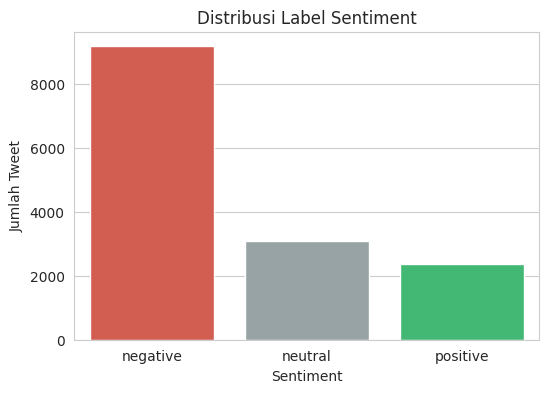

In [ ]:
df = pd.read_csv('Tweets.csv')
print("Shape dataset:", df.shape)
print("\nKolom:", df.columns.tolist())

df = df[['text', 'airline_sentiment']].dropna().reset_index(drop=True)
print("\nShape setelah ambil kolom relevan:", df.shape)

print("\nDistribusi label:")
print(df['airline_sentiment'].value_counts())
print("\nDistribusi label (%):")
print(df['airline_sentiment'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='airline_sentiment', order=['negative','neutral','positive'],
              palette={'negative':'#e74c3c','neutral':'#95a5a6','positive':'#2ecc71'})
plt.title('Distribusi Label Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Jumlah Tweet')
plt.show()

        text_length    word_count
count  14640.000000  14640.000000
mean     103.822063     17.653415
std       36.277339      6.882259
min       12.000000      2.000000
25%       77.000000     12.000000
50%      114.000000     19.000000
75%      136.000000     23.000000
max      186.000000     36.000000


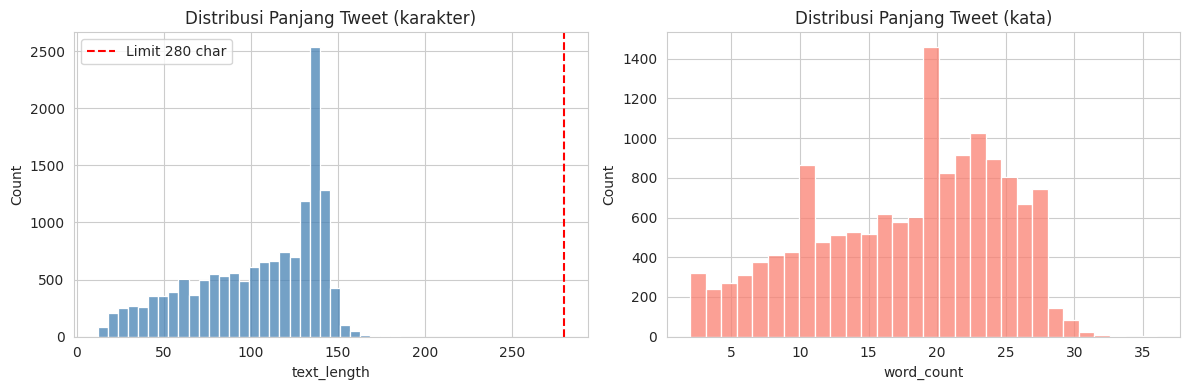

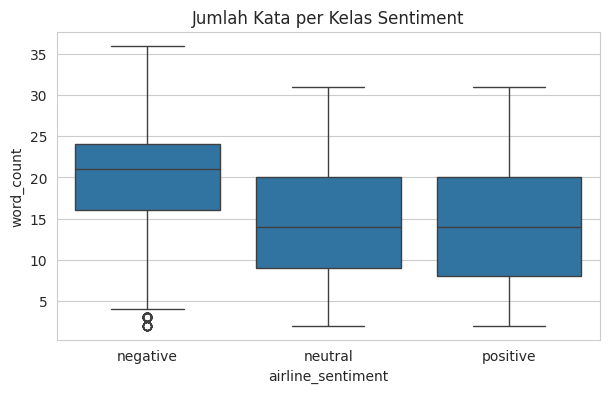

In [ ]:
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print(df[['text_length', 'word_count']].describe())

fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['text_length'], bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Distribusi Panjang Tweet (karakter)')
axes[0].axvline(280, color='red', linestyle='--', label='Limit 280 char')
axes[0].legend()

sns.histplot(df['word_count'], bins=30, ax=axes[1], color='salmon')
axes[1].set_title('Distribusi Panjang Tweet (kata)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
sns.boxplot(data=df, x='airline_sentiment', y='word_count', order=['negative','neutral','positive'])
plt.title('Jumlah Kata per Kelas Sentiment')
plt.show()

% tweet ada mention : 100.0%
% tweet ada hashtag : 16.2%
% tweet ada URL     : 8.0%

Top 15 hashtags:
  #destinationdragons: 81
  #fail: 69
  #jetblue: 48
  #unitedairlines: 45
  #customerservice: 36
  #usairways: 30
  #americanairlines: 27
  #neveragain: 27
  #united: 26
  #usairwaysfail: 26
  #disappointed: 25
  #travel: 22
  #avgeek: 22
  #help: 21
  #badservice: 21

Top 10 mentions:
  @united: 3894
  @usairways: 3000
  @americanair: 2961
  @southwestair: 2458
  @jetblue: 2248
  @virginamerica: 519
  @delta: 68
  @imaginedragons: 45
  @phlairport: 20
  @dfwairport: 17


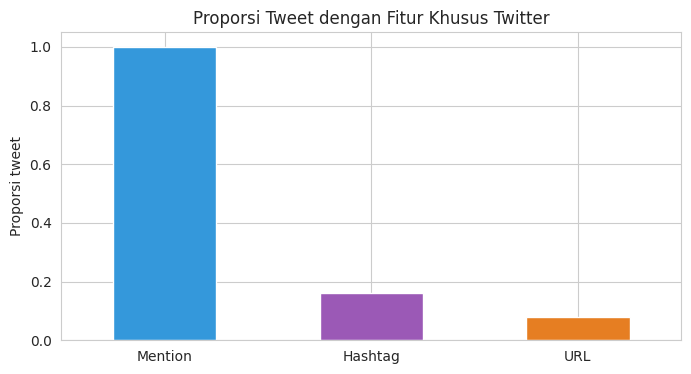

In [ ]:
df['has_mention']  = df['text'].str.contains(r'@\w+', regex=True)
df['has_hashtag']  = df['text'].str.contains(r'#\w+', regex=True)
df['has_url']      = df['text'].str.contains(r'http\S+', regex=True)
df['num_hashtags'] = df['text'].str.count(r'#\w+')
df['num_mentions'] = df['text'].str.count(r'@\w+')

print(f"% tweet ada mention : {df['has_mention'].mean()*100:.1f}%")
print(f"% tweet ada hashtag : {df['has_hashtag'].mean()*100:.1f}%")
print(f"% tweet ada URL     : {df['has_url'].mean()*100:.1f}%")

all_hashtags = re.findall(r'#(\w+)', ' '.join(df['text'].astype(str)))
top_tags = Counter([h.lower() for h in all_hashtags]).most_common(15)
print("\nTop 15 hashtags:")
for tag, cnt in top_tags:
    print(f"  #{tag}: {cnt}")

all_mentions = re.findall(r'@(\w+)', ' '.join(df['text'].astype(str)))
top_mentions = Counter([m.lower() for m in all_mentions]).most_common(10)
print("\nTop 10 mentions:")
for m, cnt in top_mentions:
    print(f"  @{m}: {cnt}")

fig, ax = plt.subplots(figsize=(8,4))
pd.Series({'Mention': df['has_mention'].mean(), 'Hashtag': df['has_hashtag'].mean(),
           'URL': df['has_url'].mean()}).plot(kind='bar', color=['#3498db','#9b59b6','#e67e22'], ax=ax)
ax.set_ylabel('Proporsi tweet')
ax.set_title('Proporsi Tweet dengan Fitur Khusus Twitter')
plt.xticks(rotation=0)
plt.show()

In [ ]:
def get_top_words(text_series, n=15):
    words = ' '.join(text_series).lower()
    words = re.sub(r'http\S+|www\.\S+', '', words)
    words = re.sub(r'@\w+', '', words)
    words = re.findall(r'\b[a-z]+\b', words)
    words = [w for w in words if w not in ENGLISH_STOP_WORDS and len(w) > 2]
    return Counter(words).most_common(n)

for label in ['negative', 'neutral', 'positive']:
    subset = df[df['airline_sentiment'] == label]['text']
    print(f"\n=== Top words - {label.upper()} ===")
    for word, cnt in get_top_words(subset):
        print(f"  {word}: {cnt}")


=== Top words - NEGATIVE ===
  flight: 2943
  cancelled: 926
  service: 750
  hours: 649
  just: 622
  help: 619
  hold: 614
  customer: 614
  time: 598
  plane: 532
  delayed: 508
  amp: 503
  hour: 452
  flightled: 448
  flights: 420

=== Top words - NEUTRAL ===
  flight: 615
  just: 173
  help: 170
  flights: 169
  need: 164
  thanks: 157
  tomorrow: 109
  fleek: 107
  know: 104
  fleet: 103
  cancelled: 101
  time: 98
  amp: 98
  way: 94
  change: 88

=== Top words - POSITIVE ===
  thanks: 611
  thank: 455
  flight: 381
  great: 236
  just: 179
  service: 162
  love: 135
  customer: 114
  guys: 110
  good: 109
  best: 105
  awesome: 100
  got: 100
  time: 97
  help: 84


In [ ]:
def clean_tweet(text):
    text = str(text).lower()                      # 1. lowercase
    text = re.sub(r'http\S+|www\.\S+', '', text)   # 2. hapus URL
    text = re.sub(r'@\w+', '', text)               # 3. hapus @mention
    text = re.sub(r'#(\w+)', r'\1', text)          # 4. hapus simbol # (pertahankan kata)
    text = re.sub(r'\brt\b', '', text)             # 5. hapus marker RT
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)     # 6. normalisasi character repetition
    text = re.sub(r'[^a-z\s]', ' ', text)          # 7. keep only alphabet + space
    text = re.sub(r'\s+', ' ', text).strip()       # 8. hapus extra whitespace
    return text

sample = "RT @VirginAmerica Whooooat a GREAT flight!!! 😊 #awesome http://t.co/xyz"
print("Sebelum:", sample)
print("Sesudah:", clean_tweet(sample))

df['clean_text'] = df['text'].apply(clean_tweet)
df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)

print("\nShape setelah cleaning:", df.shape)
print("\nContoh hasil cleaning:")
print(df[['text', 'clean_text']].head(5))

df['clean_word_count'] = df['clean_text'].str.split().str.len()
print("\nStatistik panjang kata setelah cleaning:")
print(df['clean_word_count'].describe())

Sebelum: RT @VirginAmerica Whooooat a GREAT flight!!! 😊 #awesome http://t.co/xyz
Sesudah: whooat a great flight awesome

Shape setelah cleaning: (14640, 10)

Contoh hasil cleaning:
                                                text  \
0                @VirginAmerica What @dhepburn said.   
1  @VirginAmerica plus you've added commercials t...   
2  @VirginAmerica I didn't today... Must mean I n...   
3  @VirginAmerica it's really aggressive to blast...   
4  @VirginAmerica and it's a really big bad thing...   

                                          clean_text  
0                                          what said  
1  plus you ve added commercials to the experienc...  
2  i didn t today must mean i need to take anothe...  
3  it s really aggressive to blast obnoxious ente...  
4           and it s a really big bad thing about it  

Statistik panjang kata setelah cleaning:
count    14640.000000
mean        16.462022
std          7.003941
min          1.000000
25%         11.000000


In [ ]:
MAX_VOCAB = 10000
MAX_LEN_TWEET = 40

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<UNK>')
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])
X = pad_sequences(sequences, maxlen=MAX_LEN_TWEET, padding='pre', truncating='pre')

print("Ukuran vocabulary aktual:", len(tokenizer.word_index))
print("Shape X:", X.shape)

label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
y = df['airline_sentiment'].map(label_map).values
y_onehot = to_categorical(y, num_classes=3)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=SEED, stratify=y
)

print("\nShape X_train:", X_train.shape, " X_test:", X_test.shape)
print("\nDistribusi label train (%):")
print(pd.Series(np.argmax(y_train, axis=1)).value_counts(normalize=True))
print("\nDistribusi label test (%):")
print(pd.Series(np.argmax(y_test, axis=1)).value_counts(normalize=True))

Ukuran vocabulary aktual: 11145
Shape X: (14640, 40)

Shape X_train: (11712, 40)  X_test: (2928, 40)

Distribusi label train (%):
0    0.626964
1    0.211663
2    0.161373
Name: proportion, dtype: float64

Distribusi label test (%):
0    0.626708
1    0.211749
2    0.161544
Name: proportion, dtype: float64


In [ ]:
EMBED_DIM = 100

model_gru = Sequential([
    Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN_TWEET),
    SpatialDropout1D(0.2),
    GRU(64, dropout=0.3),
    Dense(3, activation='softmax')
], name='Baseline_GRU')

model_gru.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_gru.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_gru = model_gru.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Baseline_GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_20 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_12            │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_19 (GRU)                    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
330/330 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.7079 - loss: 0.7032 - val_accuracy: 0.7628 - val_loss: 0.5819
Epoch 2/20
330/330 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8250 - loss: 0.4503 - val_accuracy: 0.7875 - val_loss: 0.5199
Epoch 3/20
330/330 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8750 - loss: 0.3319 - val_accuracy: 0.7995 - val_loss: 0.5574
Epoch 4/20
330/330 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9059 - loss: 0.2565 - val_accuracy: 0.7841 - val_loss: 0.6356
Epoch 5/20
330/330 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9268 - loss: 0.2022 - val_accuracy: 0.7765 - val_loss: 0.7142


In [ ]:
model_bigru = Sequential([
    Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN_TWEET),
    SpatialDropout1D(0.2),
    Bidirectional(GRU(64, dropout=0.3)),
    Dense(3, activation='softmax')
], name='BiGRU')

model_bigru.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_bigru.summary()

history_bigru = model_bigru.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)

Model: "BiGRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_21 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_13            │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_15                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
330/330 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.7098 - loss: 0.6968 - val_accuracy: 0.7884 - val_loss: 0.5497
Epoch 2/20
330/330 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.8229 - loss: 0.4510 - val_accuracy: 0.7875 - val_loss: 0.5363
Epoch 3/20
330/330 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8720 - loss: 0.3424 - val_accuracy: 0.7850 - val_loss: 0.5745
Epoch 4/20
330/330 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9013 - loss: 0.2629 - val_accuracy: 0.7884 - val_loss: 0.6505
Epoch 5/20
330/330 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9250 - loss: 0.2104 - val_accuracy: 0.7816 - val_loss: 0.7214


In [ ]:
model_cnn = Sequential([
    Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN_TWEET),
    SpatialDropout1D(0.2),
    Conv1D(filters=64, kernel_size=5, activation='relu', padding='same'),
    GlobalMaxPooling1D(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
], name='Conv1D')

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_cnn.summary()

history_cnn = model_cnn.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)

Model: "Conv1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_22 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_14            │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_9          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
330/330 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6783 - loss: 0.7615 - val_accuracy: 0.7730 - val_loss: 0.5881
Epoch 2/20
330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8105 - loss: 0.5124 - val_accuracy: 0.7790 - val_loss: 0.5309
Epoch 3/20
330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8686 - loss: 0.3718 - val_accuracy: 0.7816 - val_loss: 0.5465
Epoch 4/20
330/330 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9140 - loss: 0.2609 - val_accuracy: 0.7773 - val_loss: 0.6092
Epoch 5/20
330/330 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9398 - loss: 0.1911 - val_accuracy: 0.7688 - val_loss: 0.6696


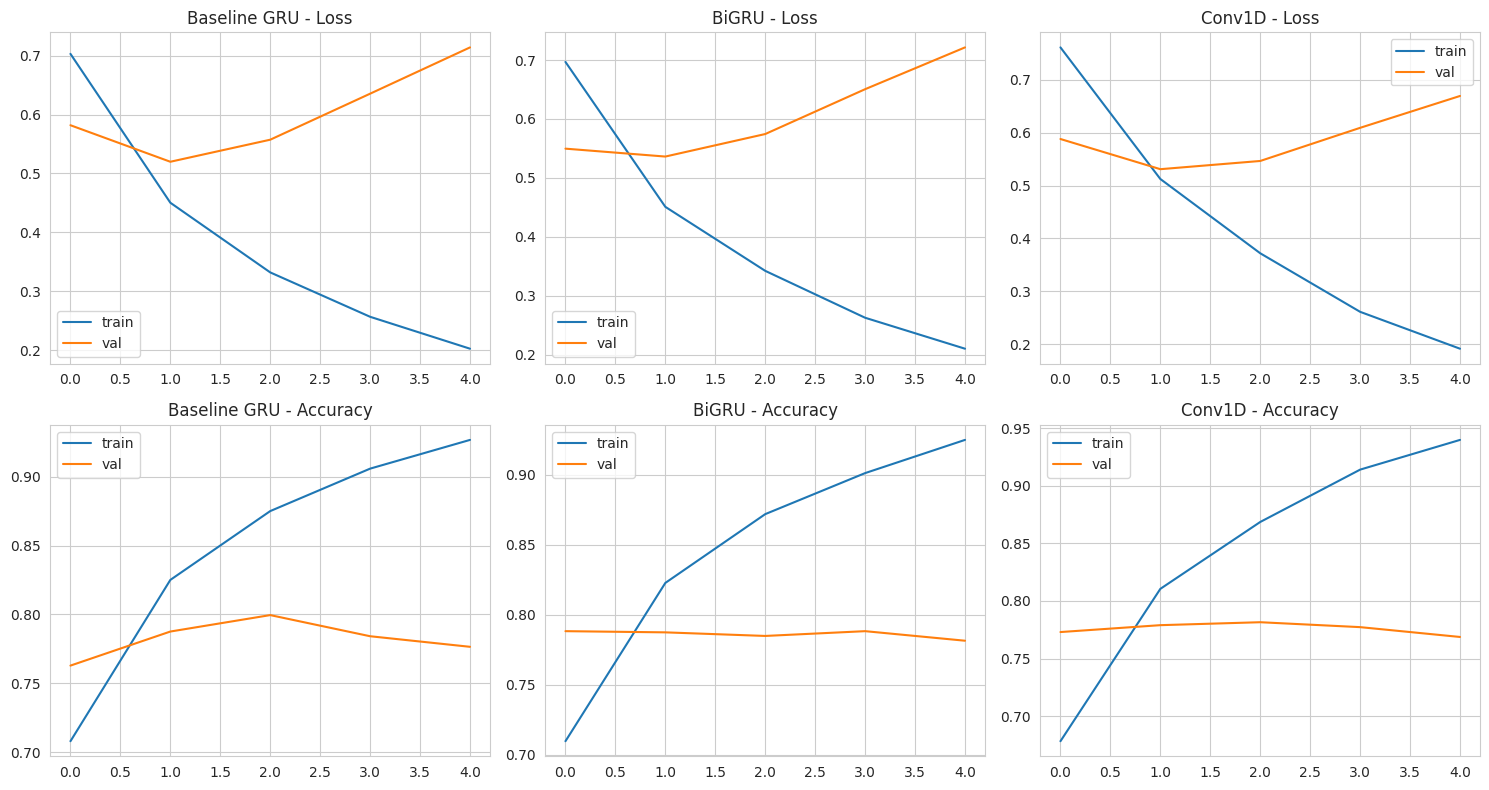

In [ ]:
histories = {'Baseline GRU': history_gru, 'BiGRU': history_bigru, 'Conv1D': history_cnn}

fig, axes = plt.subplots(2, 3, figsize=(15,8))
for i, (name, h) in enumerate(histories.items()):
    axes[0, i].plot(h.history['loss'], label='train')
    axes[0, i].plot(h.history['val_loss'], label='val')
    axes[0, i].set_title(f'{name} - Loss')
    axes[0, i].legend()

    axes[1, i].plot(h.history['accuracy'], label='train')
    axes[1, i].plot(h.history['val_accuracy'], label='val')
    axes[1, i].set_title(f'{name} - Accuracy')
    axes[1, i].legend()

plt.tight_layout()
plt.show()

In [ ]:
target_names = ['negative', 'neutral', 'positive']
models = {'Baseline GRU': model_gru, 'BiGRU': model_bigru, 'Conv1D': model_cnn}

results = []
predictions = {}

for name, model in models.items():
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)
    predictions[name] = y_pred

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision (macro)': prec,
        'Recall (macro)': rec,
        'F1-score (macro)': f1
    })

    print(f"\n=== Classification Report - {name} ===")
    print(classification_report(y_true, y_pred, target_names=target_names))

results_df = pd.DataFrame(results).sort_values('F1-score (macro)', ascending=False).reset_index(drop=True)
print("\n=== TABEL PERBANDINGAN METRIK ===")
print(results_df.to_string(index=False))


=== Classification Report - Baseline GRU ===
              precision    recall  f1-score   support

    negative       0.87      0.89      0.88      1835
     neutral       0.62      0.64      0.63       620
    positive       0.75      0.66      0.70       473

    accuracy                           0.80      2928
   macro avg       0.75      0.73      0.74      2928
weighted avg       0.80      0.80      0.80      2928


=== Classification Report - BiGRU ===
              precision    recall  f1-score   support

    negative       0.86      0.89      0.88      1835
     neutral       0.61      0.64      0.62       620
    positive       0.77      0.62      0.68       473

    accuracy                           0.79      2928
   macro avg       0.75      0.72      0.73      2928
weighted avg       0.79      0.79      0.79      2928


=== Classification Report - Conv1D ===
              precision    recall  f1-score   support

    negative       0.87      0.87      0.87      1835
    

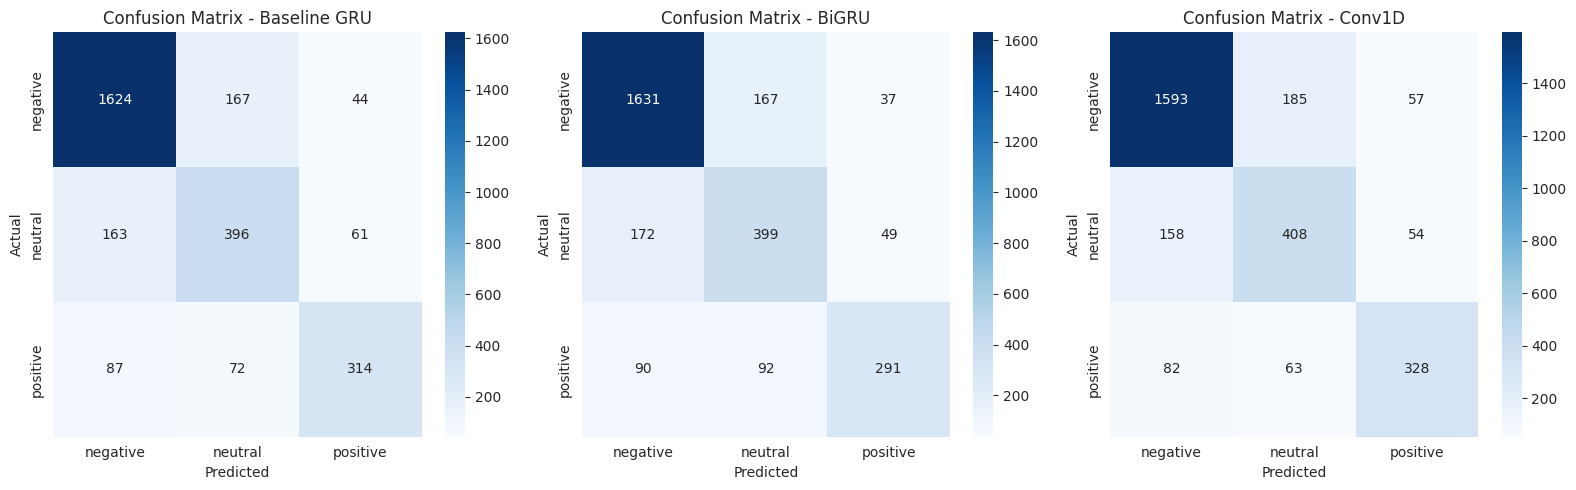


Model terbaik berdasarkan F1-macro: Conv1D

Confusion Matrix - Conv1D:
          negative  neutral  positive
negative      1593      185        57
neutral        158      408        54
positive        82       63       328


In [ ]:
y_true = np.argmax(y_test, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(16,5))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names, ax=ax)
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]['Model']
print(f"\nModel terbaik berdasarkan F1-macro: {best_model_name}")
cm_best = confusion_matrix(y_true, predictions[best_model_name])
print(f"\nConfusion Matrix - {best_model_name}:")
print(pd.DataFrame(cm_best, index=target_names, columns=target_names))

### Analisis & Kesimpulan Tugas Akhir

**Model terbaik:** Conv1D

Berdasarkan F1-macro, Conv1D menjadi model dengan performa paling seimbang di antara tiga model yang diuji. Meskipun akurasi keseluruhannya sedikit di bawah Baseline GRU, Conv1D jauh lebih baik dalam mengenali kelas minoritas (neutral dan positive). Ini terlihat dari recall kelas neutral (408 dari 620, sekitar 66%) dan positive (328 dari 473, sekitar 69%) yang lebih tinggi dibanding dua model lainnya. Karena dataset ini tidak seimbang (kelas negative jauh lebih dominan), F1-macro jadi metrik yang lebih jujur dibanding akurasi, dan di sinilah keunggulan Conv1D terlihat jelas.

**Tantangan khas dataset Twitter dibanding IMDB**

Dataset Twitter punya karakteristik yang jauh lebih sulit dibanding IMDB. Beberapa hal yang terasa selama proses ini:

- Teksnya sangat pendek (rata rata hanya belasan kata), jadi model punya informasi yang jauh lebih sedikit untuk membuat keputusan dibanding review IMDB yang panjang dan deskriptif.
- Bahasa yang digunakan informal, banyak typo, singkatan, dan slang, sehingga makna sentimen kadang tidak terlalu eksplisit.
- Ada noise khas Twitter seperti mention, hashtag, URL, dan RT marker yang harus dibersihkan dulu sebelum teks bisa diproses model.
- Distribusi label tidak seimbang, kelas negative jauh lebih banyak dibanding neutral dan positive, sehingga model cenderung lebih mudah belajar mengenali negative tapi kesulitan di dua kelas lainnya.
- Klasifikasinya juga multi kelas (3 kelas), bukan biner seperti IMDB, yang membuat batas antar kelas (terutama antara neutral dan dua kelas lainnya) jadi lebih kabur.

**Insight dari confusion matrix**

Ketiga model menunjukkan pola kesalahan yang serupa. Kelas negative paling mudah dikenali oleh semua model, dengan tingkat akurasi prediksi yang tinggi (di atas 1500 dari sekitar 1835 sampel). Sebaliknya, kelas neutral konsisten menjadi yang paling sulit. Pada ketiga model, banyak sampel neutral yang justru diprediksi sebagai negative, misalnya pada Conv1D ada 158 sampel neutral yang salah diprediksi sebagai negative.

Pola ini cukup wajar karena secara linguistik, tweet neutral sering punya nada yang netral tapi tetap menyinggung masalah (misalnya komplain ringan tanpa emosi kuat), sehingga model cenderung salah mengartikannya sebagai negative. Begitu juga sebaliknya, ada sejumlah tweet positive yang salah diprediksi sebagai negative, kemungkinan karena penggunaan sarkasme atau campuran kata positif dan negatif dalam satu tweet yang membingungkan model.

Conv1D menunjukkan perbaikan kecil tapi konsisten di kelas neutral dan positive dibanding GRU dan BiGRU, yang mengindikasikan bahwa pendekatan berbasis filter lokal (n-gram) cukup efektif menangkap pola kata kunci sentimen pada teks pendek seperti tweet, dibanding pendekatan sekuensial murni seperti GRU.

**Saran perbaikan**

- Atasi ketidakseimbangan kelas dengan teknik seperti class_weight saat training, oversampling pada kelas minoritas, atau data augmentation untuk tweet neutral dan positive.
- Gunakan pretrained word embedding seperti GloVe Twitter yang sudah dilatih pada data sosial media, sehingga representasi kata lebih relevan dibanding embedding yang dilatih dari nol.
- Coba model berbasis Transformer seperti BERT atau DistilBERT yang lebih mampu menangkap konteks dan nuansa bahasa informal.
- Tambahkan fitur tambahan seperti jumlah emoji, panjang tweet, atau skor sentimen dari lexicon based approach sebagai fitur pendukung di luar teks murni.
- Lakukan error analysis lebih mendalam khusus pada kelas neutral untuk memahami pola kesalahan secara kualitatif, misalnya dengan membaca langsung beberapa contoh tweet yang salah diklasifikasikan.

---
## Rangkuman

<table border="1" cellpadding="8" cellspacing="0">
<tr><th>Topik</th><th>Poin Penting</th></tr>
<tr><td><strong>Sequence Model</strong></td><td>Mempertahankan <em>memory</em> dari timestep sebelumnya; cocok untuk teks karena urutan kata penting</td></tr>
<tr><td><strong>GRU</strong></td><td>Gated RNN dengan 2 gate (update, reset); mengatasi vanishing gradient; lebih ringan dari LSTM</td></tr>
<tr><td><strong>BiGRU</strong></td><td>Memproses sequence dari dua arah; memberi konteks penuh untuk setiap timestep</td></tr>
<tr><td><strong>Anatomi Layer</strong></td><td>Setiap layer punya fungsi, shape transformasi, dan parameter spesifik; memahami transformasi shape adalah kunci debugging arsitektur</td></tr>
<tr><td><strong>EDA</strong></td><td>Wajib sebelum modeling — pahami distribusi label, panjang teks, dan pola khas dataset</td></tr>
<tr><td><strong>Preprocessing</strong></td><td>Padding untuk standarisasi panjang; stratified split; cleaning teks khusus untuk dataset noisy</td></tr>
<tr><td><strong>Pooling Layer</strong></td><td>GlobalMaxPool / GlobalAvgPool memanfaatkan seluruh sequence, bukan hanya hidden state terakhir</td></tr>
<tr><td><strong>Hybrid CNN+RNN</strong></td><td>Conv1D menangkap n-gram lokal, BiGRU menangkap dependency jangka panjang</td></tr>
<tr><td><strong>Evaluasi</strong></td><td>Jangan hanya accuracy — lihat precision, recall, F1; confusion matrix untuk analisis error</td></tr>
</table>

---
<center><strong>Selamat Mengerjakan!</strong></center>